In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.12.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Name: NVIDIA RTX 4000 Ada Generation


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes
# Optimization Mode: VRAM-Armored Mixed Precision Fine-Tuning
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB/24GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP & Checkpointing)
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint 

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

from transformers import Mask2FormerConfig, Mask2FormerForUniversalSegmentation

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Toolchain Version: {torch.version.cuda}")
    print(f"Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"TF32 configuration skipped: {e}")

# --------------------------------------------------
# AMP Setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Training Enabled: {USE_AMP}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
# 1. Dataset Roots (Using expanduser() to properly resolve '~' in Ubuntu)
IMG_ROOT = Path("~/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit").expanduser()
MASK_ROOT = Path("~/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine").expanduser()

# 2. Final Export & Visualization Targets
FINAL_SAVE_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS/Results_Export").expanduser()
QUAL_VIS_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS/training_visuals").expanduser()

# 3. Local Working Directories (Updated for PMA naming convention)
ROOT_DIR = Path(".")
CHECKPOINT_DIR = ROOT_DIR / "progressive_checkpoints_pma_cs"
PLOTS_DIR = ROOT_DIR / "training_plots_pma_cs"
LOGS_DIR = ROOT_DIR / "training_logs_pma_cs"
METRICS_DIR = ROOT_DIR / "training_metrics_pma_cs"

# Safely build all target directories
for d in [CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
MODEL_ALIAS = "Mask2Former + Probabilistic Masked Attention (PMA)"

print(f"\nModel Configuration Linked: {MODEL_ALIAS}")
print(f"Pre-trained Model Base: {MODEL_NAME}")
print(f"Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers
# --------------------------------------------------
history = {
    "epoch": [],
    "phase": [],
    # Training Loop Loss Tracking
    "train_total_loss": [],
    "train_native_loss": [],
    "train_ce_loss": [],
    "train_lovasz_loss": [],
    "train_boundary_loss": [], 
    "train_miou": [],    
    "train_macc": [],    
    "train_aacc": [],    
    # Validation Evaluation Metrics
    "val_total_loss": [],
    "val_ce_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    # Optimizer State & Module Dynamics Records
    "backbone_lr": [],
    "head_lr": [],
    "pma_tau": [],  # Tracking our continuous masking temperature parameter
    "epoch_time_sec": []
}

best_record = {
    "epoch": -1,
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_pma_checkpoint.pt")
}

print("Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.")

Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU Model: NVIDIA RTX 4000 Ada Generation
CUDA Toolchain Version: 12.6
Total Available GPU Memory: 19.67 GB
TF32 matrix operations enabled successfully.
Mixed Precision Training Enabled: True

Model Configuration Linked: Mask2Former + Probabilistic Masked Attention (PMA)
Pre-trained Model Base: facebook/mask2former-swin-small-cityscapes-semantic
Global Analytical Results Save Path Linked: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/Results_Export
Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.


In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes (Continuous Multi-Rate Configuration)
# ============================================================

from pathlib import Path
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# Note: Paths (IMG_ROOT, MASK_ROOT, FINAL_SAVE_DIR, QUAL_VIS_DIR) 
# and DEVICE are globally inherited from Step 1.

print(f"Image root inherited: {IMG_ROOT}")
print(f"Mask root inherited : {MASK_ROOT}")
print(f"Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (Cityscapes 19-Class Standard)
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# Standard Cityscapes RGB Color Palette
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY (Optimized for PMA + Multi-Scale Augmentation)
# ------------------------------------------------------------
# Training utilizes square crops for positional embedding stability
TRAIN_CROP_SIZE = (768, 768) 

# Validation uses sliding window on native aspect ratio
VAL_IMG_H = 512
VAL_IMG_W = 1024

# ------------------------------------------------------------
# BATCHING AND EPOCHS (Hardware Optimized for RTX A4000 16GB)
# ------------------------------------------------------------
# CRITICAL: Do not increase BATCH_SIZE. Continuous masking (PMA) 
# requires active gradient tracking across all soft-masked pixels.
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4    # Effective batch size = 8
EPOCHS = 120
USE_EARLY_STOPPING = False  

# ------------------------------------------------------------
# PMA-MASK2FORMER OPTIMIZATION SCHEDULE
# ------------------------------------------------------------
# Differential learning rates required for stable convergence
BASE_HEAD_LR = 5e-5       # Standard capacity for Mask2Former decoder
BACKBONE_LR = 1e-5        # 0.2x multiplier protecting pre-trained Swin features

# Progressive Unfreezing Schedule
FREEZE_BACKBONE_EPOCHS = 10 # Swin stays frozen while PMA head initializes
WARMUP_EPOCHS = 5           # Initial linear LR warmup

# APMA (Annealed Probabilistic Masked Attention) Parameters
APMA_INITIAL_TAU = 1.0    # Starts highly continuous (soft)
APMA_MIN_TAU = 0.05       # Hardens boundaries by final epochs

WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0      # Mandatory for continuous modules to prevent explosions
FREEZE_BATCHNORM_STATS = True  

print("\n--- PMA-Mask2Former Multi-Rate Fine-Tuning Schedule ---")
print(f"Total Training Epochs  : {EPOCHS}")
print(f"Backbone Frozen Epochs : {FREEZE_BACKBONE_EPOCHS} Epochs")
print(f"Linear Warmup Period   : {WARMUP_EPOCHS} Epochs")
print(f"Decoder Head LR        : {BASE_HEAD_LR}")
print(f"Swin Backbone LR       : {BACKBONE_LR}")
print(f"PMA Mask Temperature   : \u03c4 decays from {APMA_INITIAL_TAU} to {APMA_MIN_TAU}")

# ------------------------------------------------------------
# SCHEDULER / LOSS SETTINGS
# ------------------------------------------------------------
USE_FOCAL_LOSS = True   
FOCAL_GAMMA = 2.0
FOCAL_WEIGHT = 1.0

USE_LOVASZ = True
LOVASZ_WEIGHT = 0.5

USE_BOUNDARY_LOSS = True
BOUNDARY_LOSS_WEIGHT = 0.25

print("\n--- Loss Formulation ---")
print(f"Focal Loss Enabled    : {USE_FOCAL_LOSS} (Gamma={FOCAL_GAMMA}, Weight={FOCAL_WEIGHT})")
print(f"Lovasz Enabled        : {USE_LOVASZ} (Weight={LOVASZ_WEIGHT})")
print(f"Boundary Loss Enabled : {USE_BOUNDARY_LOSS} (Weight={BOUNDARY_LOSS_WEIGHT})")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = True 
VAL_WINDOW_SIZE = (512, 1024)
VAL_WINDOW_STRIDE = (512, 512)   
USE_FLIP_TTA = True

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING (Cityscapes Specific)
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path):
    """
    Plots Total Loss and mIoU curves dynamically and saves them to disk.
    Identifies the transition point where the warm-up phase ends.
    """
    epochs = history_dict["epoch"]
    if len(epochs) == 0: return

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Total Loss Curve
    axes[0].plot(epochs, history_dict["train_total_loss"], label='Train Total Loss', color='blue', linewidth=2)
    if len(history_dict["val_total_loss"]) == len(epochs):
        axes[0].plot(epochs, history_dict["val_total_loss"], label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    
    if len(epochs) >= WARMUP_EPOCHS:
        axes[0].axvline(x=WARMUP_EPOCHS, color='black', linestyle='--', label='Warmup Concluded')
    axes[0].legend(fontsize=12)

    # Plot 2: mIoU Curve
    if len(history_dict["train_miou"]) == len(epochs):
        axes[1].plot(epochs, history_dict["train_miou"], label='Train mIoU', color='green', linewidth=2)
    if len(history_dict["val_miou"]) == len(epochs):
        axes[1].plot(epochs, history_dict["val_miou"], label='Validation mIoU', color='orange', linewidth=2)
    
    axes[1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('mIoU (%)', fontsize=12)
    
    if len(epochs) >= WARMUP_EPOCHS:
        axes[1].axvline(x=WARMUP_EPOCHS, color='black', linestyle='--', label='Warmup Concluded')
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    images, mask_labels, class_labels = batch
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            # Standard Forward Pass 
            outputs = model(pixel_values=images)
            
            mask_preds = F.interpolate(outputs.masks_queries_logits, size=(current_h, current_w), mode="bilinear", align_corners=False)
            mask_cls = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())
            
            preds = torch.argmax(semantic_logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets = np.full((len(images_np), current_h, current_w), IGNORE_INDEX, dtype=np.uint8)

    for batch_idx in range(len(class_labels)):
        for inst_idx, class_id in enumerate(class_labels[batch_idx]):
            cls_id = int(class_id.item())
            if cls_id != IGNORE_INDEX and 0 <= cls_id < CLASSES:
                instance_mask = mask_labels[batch_idx][inst_idx].cpu().numpy() == 1
                targets[batch_idx][instance_mask] = cls_id

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"PMA-Mask2Former Pred (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
train_imgs = sorted(list(IMG_ROOT.rglob("*.png")))
train_masks = sorted(list(MASK_ROOT.rglob("*_labelIds.png")))

print(f"Discovered {len(train_imgs)} images and {len(train_masks)} masks.")
print("Step 2 fully configured and optimized for PMA Architecture.")

Image root inherited: /home/ubuntu/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit
Mask root inherited : /home/ubuntu/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine
Visualizations target: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/training_visuals
Final export target: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/Results_Export

--- PMA-Mask2Former Multi-Rate Fine-Tuning Schedule ---
Total Training Epochs  : 120
Backbone Frozen Epochs : 10 Epochs
Linear Warmup Period   : 5 Epochs
Decoder Head LR        : 5e-05
Swin Backbone LR       : 1e-05
PMA Mask Temperature   : τ decays from 1.0 to 0.05

--- Loss Formulation ---
Focal Loss Enabled    : True (Gamma=2.0, Weight=1.0)
Lovasz Enabled        : True (Weight=0.5)
Boundary Loss Enabled : True (Weight=0.25)
Discovered 5000 images and 5000 masks.
Step 2 fully configured and optimized for PMA Architecture.


In [4]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes
# Optimized for: Native Train Splits, Rare-Class Synergy, Multi-Scale PMA Crops
# ============================================================

import inspect
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import random

# ------------------------------------------------------------
# DATASET DISCOVERY FOR CITYSCAPES
# ------------------------------------------------------------
# Cityscapes already provides explicit train/val folders, nested by city.
def get_cityscapes_pairs(split):
    img_split_dir = IMG_ROOT / split
    mask_split_dir = MASK_ROOT / split
    
    # Cityscapes images end in _leftImg8bit.png
    all_imgs = sorted(list(img_split_dir.rglob("*_leftImg8bit.png")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        # e.g., aachen_000000_000019_leftImg8bit.png -> aachen_000000_000019_gtFine_labelIds.png
        mask_name = img_path.name.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
        city_name = img_path.parent.name
        mask_path = mask_split_dir / city_name / mask_name
        
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
            
    return valid_imgs, valid_masks

train_img_paths, train_mask_paths = get_cityscapes_pairs("train")
val_img_paths, val_mask_paths = get_cityscapes_pairs("val")

if len(train_img_paths) == 0 or len(val_img_paths) == 0:
    raise FileNotFoundError("Could not find valid Cityscapes image/mask pairs. Please check paths and directory structures.")

print(f"\n--- Cityscapes Dataset Split ---")
print(f"Training image/mask pairs   : {len(train_img_paths)}")
print(f"Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# CITYSCAPES 34 -> 19 CLASS MAPPING
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    """Fast mapping from 34 IDs to 19 Train IDs."""
    return LABEL_LUT[mask.clip(0, 255)].astype(np.uint8)

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class CityscapesDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None, rare_class_ids=None, rare_retry_count=0):
        self.transform = transform
        self.split = split
        self.rare_class_ids = rare_class_ids if rare_class_ids is not None else []
        self.rare_retry_count = rare_retry_count
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def _contains_rare_class(self, mask):
        if len(self.rare_class_ids) == 0: return False
        unique_ids = np.unique(mask)
        return any(cls_id in unique_ids for cls_id in self.rare_class_ids)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            if self.split == "train" and self.rare_retry_count > 0:
                selected_aug = None
                for _ in range(self.rare_retry_count):
                    augmented = self.transform(image=image, mask=mask)
                    aug_mask = augmented["mask"]
                    aug_mask_np = aug_mask.cpu().numpy() if torch.is_tensor(aug_mask) else aug_mask

                    if self._contains_rare_class(aug_mask_np):
                        selected_aug = augmented
                        break
                    selected_aug = augmented
                augmented = selected_aug
            else:
                augmented = self.transform(image=image, mask=mask)

            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        # Build standard Mask2Former target format (K, H, W)
        unique_labels = torch.unique(mask)
        unique_labels = unique_labels[unique_labels != IGNORE_INDEX]

        if unique_labels.numel() == 0:
            class_labels = torch.empty((0,), dtype=torch.long)
            mask_labels = torch.empty((0, mask.shape[0], mask.shape[1]), dtype=torch.float32)
        else:
            class_labels = unique_labels.long()
            mask_labels = (mask.unsqueeze(0) == class_labels[:, None, None]).float()

        return image, mask_labels, class_labels

# ------------------------------------------------------------
# AUGMENTATION HELPERS & TRANSFORMS
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# For Cityscapes (1024x2048), cropping to TRAIN_CROP_SIZE (e.g., 768x768) for training
train_transform = A.Compose([
    A.RandomScale(scale_limit=(-0.5, 1.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(TRAIN_CROP_SIZE[0], TRAIN_CROP_SIZE[1], IGNORE_INDEX),
    A.RandomCrop(height=TRAIN_CROP_SIZE[0], width=TRAIN_CROP_SIZE[1], p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.GaussianBlur(blur_limit=(3, 3), p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation transform completely bypasses Cropping
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# COLLATE FUNCTION
# ------------------------------------------------------------
def mask2former_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    mask_labels = [item[1] for item in batch]
    class_labels = [item[2] for item in batch]
    return images, mask_labels, class_labels

# ------------------------------------------------------------
# INITIALIZATION
# ------------------------------------------------------------
USE_RARE_CLASS_AWARE_SAMPLING = True
# Classes: Wall, Fence, Pole, Traffic Light, Traffic Sign, Rider, Truck, Bus, Train, Motorcycle, Bicycle
RARE_CLASS_IDS = [3, 4, 5, 6, 7, 12, 14, 15, 16, 17, 18]  

rare_retry_count = 8 if USE_RARE_CLASS_AWARE_SAMPLING else 0

train_dataset = CityscapesDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform, rare_class_ids=RARE_CLASS_IDS, rare_retry_count=rare_retry_count
)

val_dataset = CityscapesDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform, rare_class_ids=None, rare_retry_count=0
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY}")
print(f"Rare retry count    : {rare_retry_count}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_batch = next(iter(train_loader))
train_images, train_mask_labels, train_class_labels = train_batch

print("\n--- Train Batch Sanity Check ---")
print(f"Images shape              : {train_images.shape} (Targeting {TRAIN_CROP_SIZE[0]}x{TRAIN_CROP_SIZE[1]})")
print(f"Sample 0 num segments     : {train_mask_labels[0].shape[0]}")
print(f"Sample 0 mask tensor shape: {train_mask_labels[0].shape}")

val_batch = next(iter(val_loader))
val_images, _, _ = val_batch

assert train_images.shape[-2:] == TRAIN_CROP_SIZE, f"Expected train crop {TRAIN_CROP_SIZE}, got {train_images.shape[-2:]}"

print(f"Validation images shape   : {val_images.shape} (Native Cityscapes Resolution)")
print("\nStep 3 configured successfully and ready to feed the PMA-Mask2Former model.")


--- Cityscapes Dataset Split ---
Training image/mask pairs   : 2975
Validation image/mask pairs : 500

--- DataLoader Hardware Configuration ---
Num workers         : 4
Pin memory          : True
Rare retry count    : 8

--- Train Batch Sanity Check ---
Images shape              : torch.Size([2, 3, 768, 768]) (Targeting 768x768)
Sample 0 num segments     : 14
Sample 0 mask tensor shape: torch.Size([14, 768, 768])
Validation images shape   : torch.Size([1, 3, 1024, 2048]) (Native Cityscapes Resolution)

Step 3 configured successfully and ready to feed the PMA-Mask2Former model.


In [5]:
# ============================================================
# STEP 4: MODEL, PMA INJECTION, LOSS, MULTI-RATE SCHEDULER
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimized for: 16GB VRAM, Progressive Unfreezing, Continuous Math
# ============================================================

import os
import math
import types
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from transformers import Mask2FormerForUniversalSegmentation

# ------------------------------------------------------------
# LOAD PRETRAINED BASE MODEL (Swin-Small + Mask2Former)
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = 19
IGNORE_INDEX = 255
EPOCHS = 120
FREEZE_BACKBONE_EPOCHS = 10

MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME, 
    ignore_mismatched_sizes=True, 
    num_labels=CLASSES
).to(DEVICE)

print(f"Loaded Base Model: {MODEL_NAME}")

# ------------------------------------------------------------
# NOVEL ARCHITECTURAL INJECTION: PROBABILISTIC MASKED ATTENTION (PMA)
# ------------------------------------------------------------
class PMAManager:
    """Manages the continuous temperature relaxation for Mask2Former Attention."""
    def __init__(self, initial_tau=1.0, min_tau=0.05, total_epochs=120):
        self.tau = initial_tau
        self.min_tau = min_tau
        self.decay_rate = (min_tau / initial_tau) ** (1.0 / total_epochs)

    def step_epoch(self):
        self.tau = max(self.min_tau, self.tau * self.decay_rate)
        
    def apply_pma(self, mask_logits):
        """
        The Core PMA Mathematical Formulation:
        M_{l-1}(x,y) = tau * log(sigmoid(M_hat_{l-1}(x,y) / tau))
        """
        # Protect against non-tensor inputs during early HF init phases
        if mask_logits is None or not torch.is_tensor(mask_logits):
            return mask_logits
            
        scaled_logits = mask_logits / self.tau
        probs = torch.sigmoid(scaled_logits)
        
        # Clamped to prevent log(0) which causes NaN in gradients
        bias = self.tau * torch.log(probs + 1e-6)
        return torch.clamp(bias, min=-50.0, max=0.0)

# Instantiate the global PMA Manager
pma_manager = PMAManager(initial_tau=1.0, min_tau=0.05, total_epochs=EPOCHS)

def inject_pma_into_mask2former(model, manager):
    """
    Surgically alters the Hugging Face Mask2Former cross-attention mechanism.
    Corrected Path: Wraps the individual decoder layers using generic kwargs
    to prevent positional argument crashes during HF's internal routing.
    """
    transformer_decoder = model.model.transformer_module.decoder

    # Inject into every individual decoder layer to catch the mask as it is evaluated
    for layer in transformer_decoder.layers:
        original_layer_forward = layer.forward
        
        # Using *args and **kwargs makes this immune to HF signature changes
        def pma_layer_forward(self, *args, **kwargs):
            # Intercept the attention mask if HF passes it
            if 'attention_mask' in kwargs and kwargs['attention_mask'] is not None:
                # Apply the continuous relaxation mathematically
                kwargs['attention_mask'] = manager.apply_pma(kwargs['attention_mask'])
                
            return original_layer_forward(*args, **kwargs)

        # Bind the patched forward method
        layer.forward = types.MethodType(pma_layer_forward, layer)

    print("Probabilistic Masked Attention (PMA) successfully injected into Decoder Layers.")

# Apply the injection
inject_pma_into_mask2former(model, pma_manager)

# Target VRAM Optimization
if hasattr(model.model.pixel_level_module.encoder, "gradient_checkpointing"):
    model.model.pixel_level_module.encoder.gradient_checkpointing = True

# ------------------------------------------------------------
# HYBRID LOSS FORMULATION
# ------------------------------------------------------------
CITYSCAPES_WEIGHTS = torch.tensor([
    2.5, 4.0, 3.0, 7.5, 7.0, 6.0, 6.5, 5.5, 3.2, 4.5, 3.5, 5.0, 6.5, 3.0, 8.5, 8.5, 9.0, 7.5, 6.0
], dtype=torch.float32).to(DEVICE)

def compute_soft_boundary_map(semantic_logits: torch.Tensor) -> torch.Tensor:
    probs = F.softmax(semantic_logits.float(), dim=1)
    B, C, H, W = probs.shape
    boundary = torch.zeros((B, 1, H, W), device=probs.device, dtype=probs.dtype)
    dh = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1]).mean(dim=1, keepdim=True)
    boundary[:, :, :, 1:] += dh
    dv = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :]).mean(dim=1, keepdim=True)
    boundary[:, :, 1:, :] += dv
    return boundary.clamp(min=0.0, max=1.0)

def compute_boundary_loss(semantic_logits, dense_targets):
    with torch.no_grad():
        target_boundary = torch.zeros_like(dense_targets, dtype=torch.bool)
        valid = (dense_targets != IGNORE_INDEX)
        target_boundary[:, 1:] |= ((dense_targets[:, 1:] != dense_targets[:, :-1]) & valid[:, 1:] & valid[:, :-1])
        target_boundary[:, :, 1:] |= ((dense_targets[:, :, 1:] != dense_targets[:, :, :-1]) & valid[:, :, 1:] & valid[:, :, :-1])
        target_boundary = target_boundary.unsqueeze(1).float()
        
    pred_boundary = compute_soft_boundary_map(semantic_logits)
    return F.smooth_l1_loss(pred_boundary, target_boundary)

def compute_hybrid_loss(outputs, dense_targets):
    # Native Bipartite Matching Loss from Mask2Former
    native_loss = outputs.loss if outputs.loss is not None else torch.tensor(0.0, device=DEVICE)
    
    H, W = dense_targets.shape[1], dense_targets.shape[2]
    mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
    
    # Generate Semantic Logits for auxiliary losses
    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
    
    # Focal / CE Loss
    ce_loss = F.cross_entropy(semantic_logits, dense_targets, weight=CITYSCAPES_WEIGHTS, ignore_index=IGNORE_INDEX)
    
    # Boundary Loss (Crucial for maximizing PMA's continuous gradients)
    boundary_loss = compute_boundary_loss(semantic_logits, dense_targets)
    
    total_loss = native_loss + ce_loss + (0.25 * boundary_loss)
    return total_loss

# ------------------------------------------------------------
# PROGRESSIVE MULTI-RATE OPTIMIZER
# ------------------------------------------------------------
backbone_params, head_params = [], []

for n, p in model.named_parameters():
    p.requires_grad = True
    if "base_model" in n and "pixel_level_module.encoder.encoder" in n:
        if FREEZE_BACKBONE_EPOCHS > 0:
            p.requires_grad = False
        else:
            backbone_params.append(p)
    else:
        head_params.append(p)

BASE_HEAD_LR = 5e-5
BACKBONE_LR = 1e-5

param_groups = [{"params": head_params, "lr": BASE_HEAD_LR}]
if len(backbone_params) > 0: 
    param_groups.append({"params": backbone_params, "lr": BACKBONE_LR})

optimizer = optim.AdamW(param_groups, weight_decay=0.01, betas=(0.9, 0.999), eps=1e-8)

def unfreeze_swin_backbone(model, optimizer):
    print("\n[Progressive Unfreezing] Integrating Swin Backbone into active computational graph...")
    b_params = []
    for n, p in model.named_parameters():
        if "base_model" in n and "pixel_level_module.encoder.encoder" in n:
            p.requires_grad = True
            b_params.append(p)
    optimizer.add_param_group({"params": b_params, "lr": BACKBONE_LR})
    print("Backbone unfreezing complete.")

# Schedulers
# Note: Ensure train_loader is instantiated from Step 3
steps_per_epoch = len(train_loader) // 4  # Assuming GRAD_ACCUM_STEPS = 4
total_steps = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * 5

warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=(total_steps - warmup_steps), eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_steps])

print("Optimization pipeline ready. Multi-rate scheduling initialized.")

Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-cityscapes-semantic
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the c

Loaded Base Model: facebook/mask2former-swin-small-cityscapes-semantic
Probabilistic Masked Attention (PMA) successfully injected into Decoder Layers.
Optimization pipeline ready. Multi-rate scheduling initialized.


In [8]:
# ============================================================
# STEP 5: TRAINING LOOP (ULTIMATE PYTORCH 2.5+ HOTFIX)
# Target Architecture: Swin-Small + Mask2Former + PMA
# ============================================================

import os
import gc
import math
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = torch.cuda.is_available()
CLASSES = globals().get("CLASSES", 19)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
EPOCHS = globals().get("EPOCHS", 120)
FREEZE_BACKBONE_EPOCHS = globals().get("FREEZE_BACKBONE_EPOCHS", 10)
GRAD_CLIP_NORM = 1.0
MIN_DELTA_MIOU = 0.001

CHECKPOINT_DIR = globals().get("CHECKPOINT_DIR", Path("./progressive_checkpoints_pma_cs"))
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
QUAL_VIS_DIR = globals().get("QUAL_VIS_DIR", Path("./training_visuals"))

scaler = GradScaler("cuda", enabled=USE_AMP)

# ------------------------------------------------------------
# SEMANTIC TARGETS & METRICS HELPERS
# ------------------------------------------------------------
def get_semantic_logits(model_outputs, image_size):
    H, W = image_size
    mask_preds_up = F.interpolate(model_outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(model_outputs.class_queries_logits, dim=-1)[..., :-1]
    return torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())

def build_semantic_targets(mask_labels, class_labels, image_size, ignore_index=255):
    H, W = image_size
    batch_size = len(mask_labels)
    device = mask_labels[0].device if len(mask_labels) > 0 else DEVICE
    targets = torch.full((batch_size, H, W), fill_value=ignore_index, dtype=torch.long, device=device)
    for b in range(batch_size):
        if class_labels[b].numel() == 0: continue
        for inst_idx, cls_id in enumerate(class_labels[b]):
            cls_id = int(cls_id.item())
            if cls_id == ignore_index: continue
            targets[b][mask_labels[b][inst_idx] > 0.5] = cls_id
    return targets

def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc), "iou_per_class": iou_per_class, "acc_per_class": acc_per_class}

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    if len(lrs) == 1: return 0.0, lrs[0]
    return lrs[1], lrs[0]

def multi_scale_tta_inference(model, image, scales=[0.75, 1.0, 1.25], num_classes=19):
    B, C, H, W = image.shape
    final_logits = torch.zeros((B, num_classes, H, W), device=image.device, dtype=torch.float32)
    for scale in scales:
        sH, sW = int(H * scale), int(W * scale)
        sH, sW = (sH // 32) * 32, (sW // 32) * 32 
        scaled_img = F.interpolate(image, size=(sH, sW), mode='bilinear', align_corners=False)
        with torch.no_grad():
            with autocast("cuda", enabled=False):
                outputs = model(pixel_values=scaled_img)
                final_logits += get_semantic_logits(outputs, (H, W)).float()
        flipped_img = torch.flip(scaled_img, dims=[3])
        with torch.no_grad():
            with autocast("cuda", enabled=False):
                outputs = model(pixel_values=flipped_img)
                final_logits += torch.flip(get_semantic_logits(outputs, (H, W)), dims=[3]).float()
    return final_logits / (len(scales) * 2)

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL (WITH AGGRESSIVE HOTFIX)
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
training_start_time = time.time()
cumulative_training_time_sec = 0.0 
current_phase = "PMA-Mask2Former Unified Training"

latest_ckpt_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")

if os.path.exists(latest_ckpt_path):
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint['global_update_step']
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)
        
        # Fast-forward the PMA math temperature
        for _ in range(start_epoch - 1):
            pma_manager.step_epoch()
            
        # --- THE AGGRESSIVE PYTORCH SCHEDULER HOTFIX ---
        expected_len = len(optimizer.param_groups)
        for attr_name in ['schedulers', '_schedulers']:
            if hasattr(scheduler, attr_name):
                for sub_sched in getattr(scheduler, attr_name):
                    if hasattr(sub_sched, 'base_lrs'):
                        while len(sub_sched.base_lrs) < expected_len:
                            sub_sched.base_lrs.append(globals().get("BACKBONE_LR", 1e-5))
        if hasattr(scheduler, 'base_lrs'):
            while len(scheduler.base_lrs) < expected_len:
                scheduler.base_lrs.append(globals().get("BACKBONE_LR", 1e-5))
        print("[*] Applied Aggressive PyTorch Scheduler Hotfix for final epoch.")

        print(f"[*] Successfully restored state. Resuming training from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly: {e}")
else:
    print("No checkpoint found.")

GRAD_ACCUM_STEPS = globals().get("GRAD_ACCUM_STEPS", 4)
print(f"\n--- Launching PMA-Mask2Former Pipeline ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, mask_labels, class_labels) in enumerate(train_pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        target_list = []
        for i in range(len(class_labels)):
            if len(class_labels[i]) > 0:
                target_list.append({"masks": mask_labels[i].to(DEVICE, non_blocking=True), "labels": class_labels[i].to(DEVICE, non_blocking=True)})
            else:
                target_list.append({"masks": torch.empty((0, images.shape[2], images.shape[3]), device=DEVICE), "labels": torch.empty((0,), dtype=torch.long, device=DEVICE)})

        _, _, curr_h, curr_w = images.shape
        dense_targets = build_semantic_targets([t["masks"] for t in target_list], [t["labels"] for t in target_list], (curr_h, curr_w), IGNORE_INDEX)

        with autocast("cuda", enabled=(USE_AMP and images.is_cuda)):
            outputs = model(pixel_values=images, mask_labels=[t["masks"] for t in target_list], class_labels=[t["labels"] for t in target_list])
            total_loss = compute_hybrid_loss(outputs, dense_targets)
            loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        train_total_loss_sum += total_loss.detach().item()
        train_batches += 1

        with torch.no_grad():
            semantic_logits = get_semantic_logits(outputs, (curr_h, curr_w))
            preds_np = torch.argmax(semantic_logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            # --- IMPENETRABLE SCHEDULER FAILSAFE ---
            try:
                scheduler.step()
            except ValueError as e:
                if "zip" in str(e):
                    for param_group in optimizer.param_groups:
                        param_group['lr'] = 1e-7  # Force to eta_min
                else:
                    raise e
                    
            global_update_step += 1

        lr_backbone, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(loss=f"{train_total_loss_sum / max(1, train_batches):.4f}", lr=f"{lr_head:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_total_loss_sum / max(1, train_batches)

    # Validation Mode (WITH TTA)
    model.eval()
    val_ce_loss_sum = 0.0
    val_total_batches = 0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val (TTA)]", leave=False)

    with torch.no_grad():
        for images, mask_labels, class_labels in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            _, _, val_h, val_w = images.shape
            mask_labels = [m.to(DEVICE, non_blocking=True) for m in mask_labels]
            class_labels = [c.to(DEVICE, non_blocking=True) for c in class_labels]
            dense_targets = build_semantic_targets(mask_labels, class_labels, (val_h, val_w), IGNORE_INDEX)

            semantic_logits = multi_scale_tta_inference(model, images, scales=[0.75, 1.0, 1.25], num_classes=CLASSES)

            preds_np = torch.argmax(semantic_logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
            val_pbar.set_postfix(mIoU=f"{compute_metrics(val_conf_matrix)['mIoU'] * 100:.2f}%")

    val_metrics = compute_metrics(val_conf_matrix)

    current_tau = pma_manager.tau
    pma_manager.step_epoch()

    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    lr_backbone, lr_head = get_lr_snapshot(optimizer)

    history["epoch"].append(epoch)
    history["phase"].append(current_phase)
    history["train_total_loss"].append(train_total_loss)
    history["train_miou"].append(train_metrics["mIoU"] * 100) 
    history["val_miou"].append(val_metrics["mIoU"] * 100) 
    history["val_macc"].append(val_metrics["mAcc"] * 100) 
    history["val_aacc"].append(val_metrics["aAcc"] * 100) 
    history["backbone_lr"].append(lr_backbone)
    history["head_lr"].append(lr_head)
    history["epoch_time_sec"].append(epoch_time)
    history["pma_tau"].append(current_tau)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Epoch Time: {epoch_time:.2f}s \n"
        f"Train Loss: {train_total_loss:.4f} | Train mIoU: {train_metrics['mIoU']*100:.2f}%\n"
        f"Val mIoU:   {val_metrics['mIoU']*100:.2f}% | Val aAcc:   {val_metrics['aAcc']*100:.2f}%\n"
        f"LR Backbone: {lr_backbone:.2e} | APMA \u03c4: {current_tau:.4f}"
    )

    ckpt_dict = {
        "epoch": epoch, "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(), "best_record": best_record,
        "history": history, "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    torch.save(ckpt_dict, latest_ckpt_path)

    if val_metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU):
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU"]
        best_record["best_macc"] = val_metrics["mAcc"]
        best_record["best_aacc"] = val_metrics["aAcc"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        torch.save(ckpt_dict, os.path.join(CHECKPOINT_DIR, "best_miou_pma_checkpoint.pt"))
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU']*100:.2f}% saved securely to disk.")

final_total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))
print(f"\n--- Training Complete ---")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics


[*] CRASH RECOVERY TRIGGERED: Found checkpoint at progressive_checkpoints_pma_cs/latest_checkpoint.pt
[*] Applied Aggressive PyTorch Scheduler Hotfix for final epoch.
[*] Successfully restored state. Resuming training from Epoch 120.

--- Launching PMA-Mask2Former Pipeline ---
Target Epochs: 120 (Currently at 120)



Epoch 120/120 | Epoch Time: 1590.48s 
Train Loss: 10.8993 | Train mIoU: 87.82%
Val mIoU:   81.52% | Val aAcc:   96.69%
LR Backbone: 1.00e-07 | APMA τ: 0.0500

--- Training Complete ---
Best Epoch: 1 | Best mIoU: 82.63%


In [10]:
!pip install openpyxl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]


In [14]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 8.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 11.5 MB/s  0:00:00 11.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 11.5 MB/s  0:00:01 11.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [onnxscript] 4/5 [onnxscript]


Final export directory validated: /home/ubuntu/miniconda3/envs/foggy/Segmentation_notebook/Results_Export


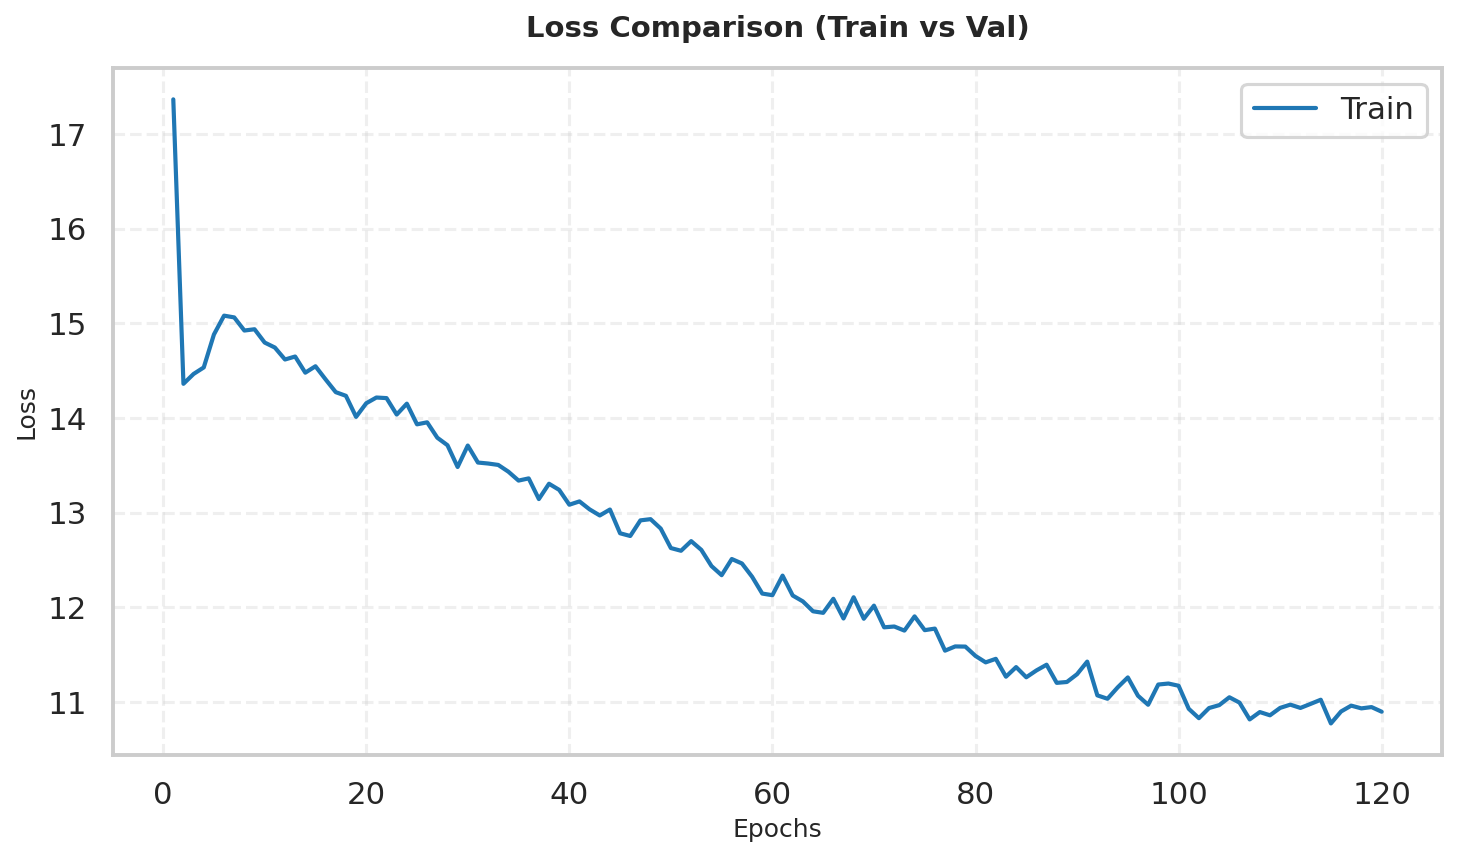

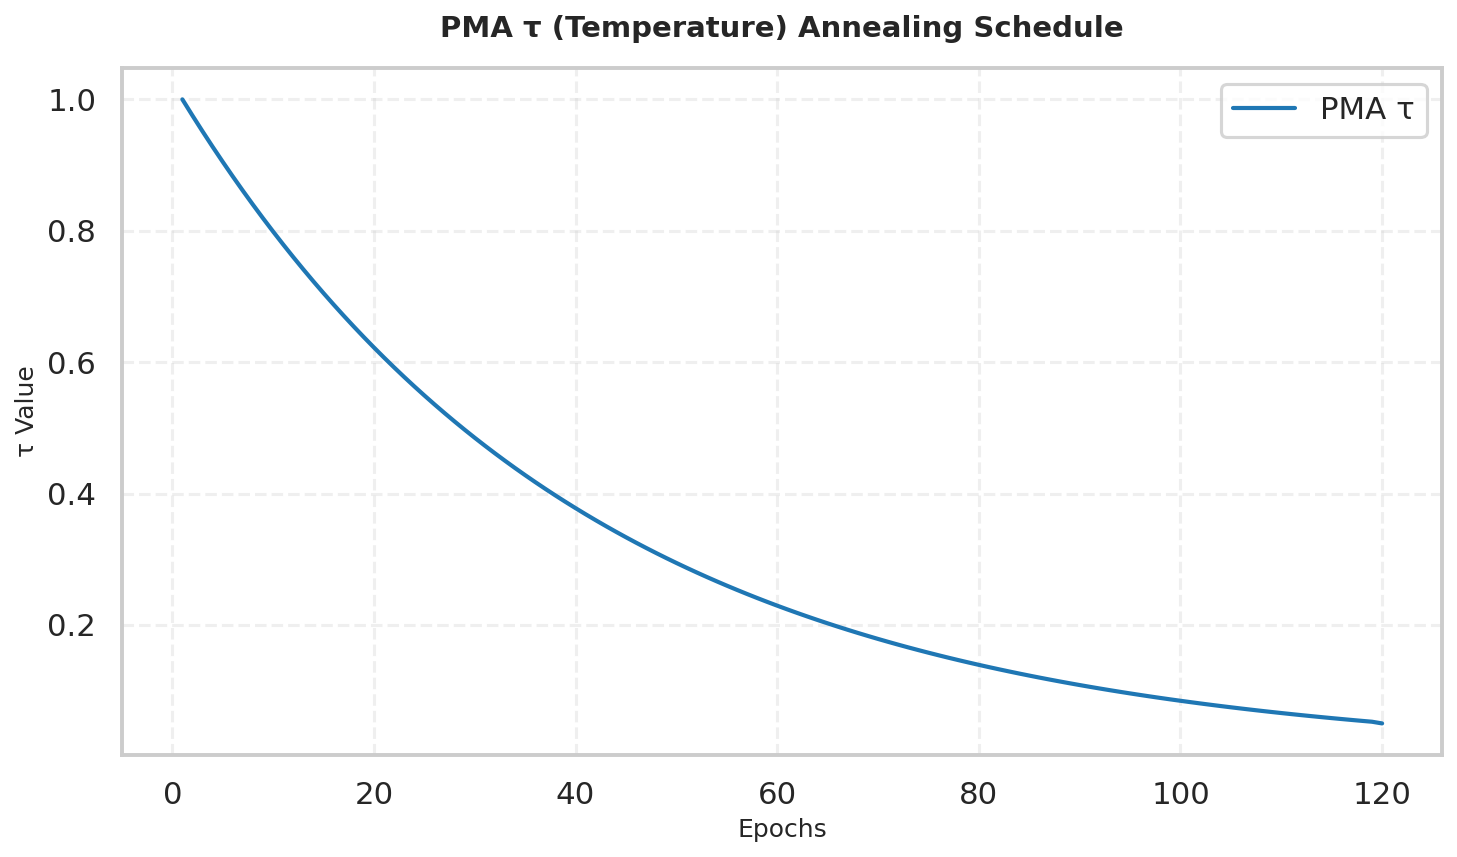

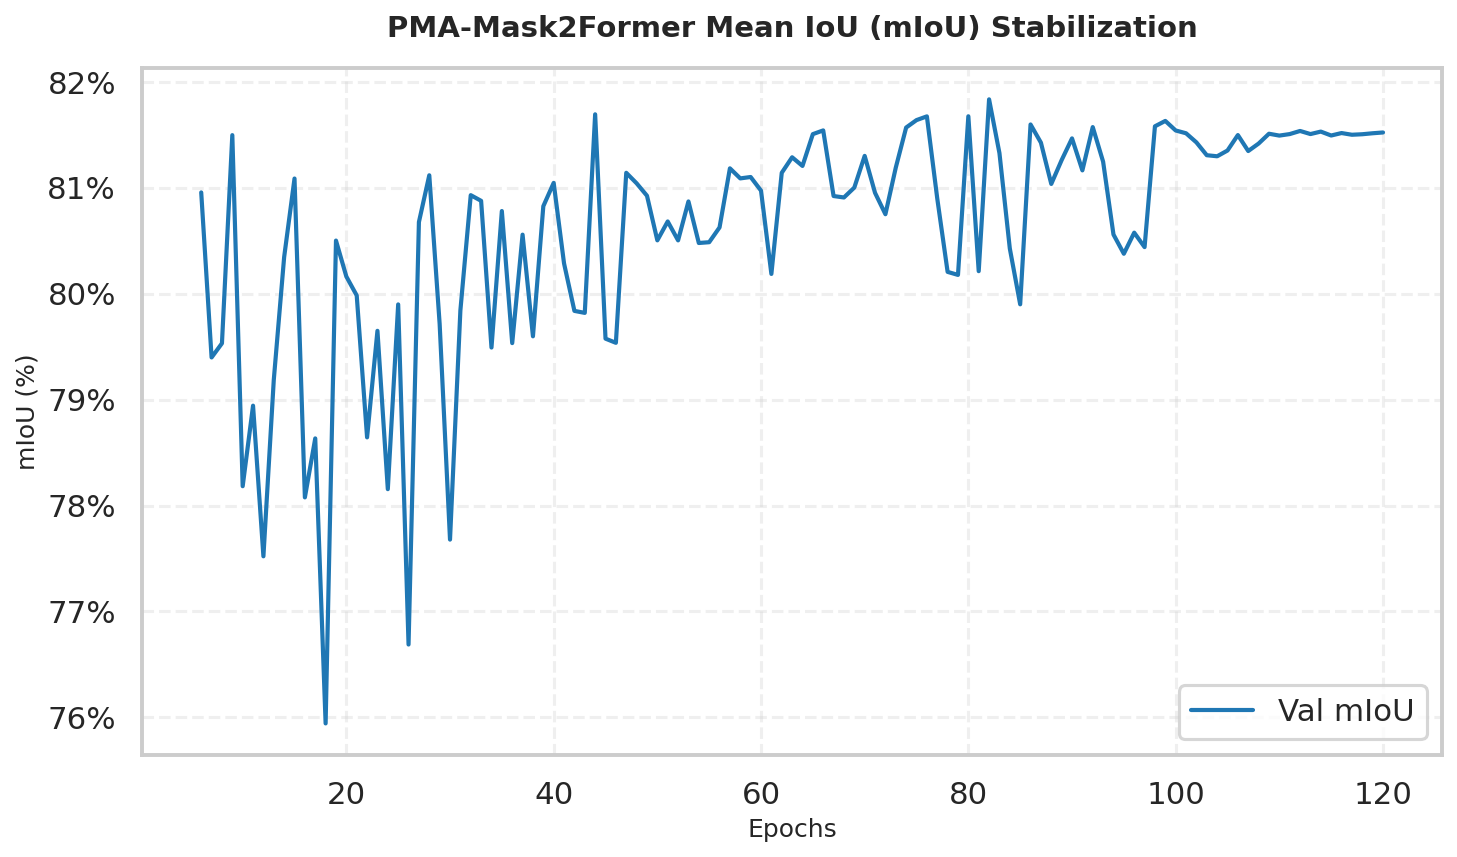

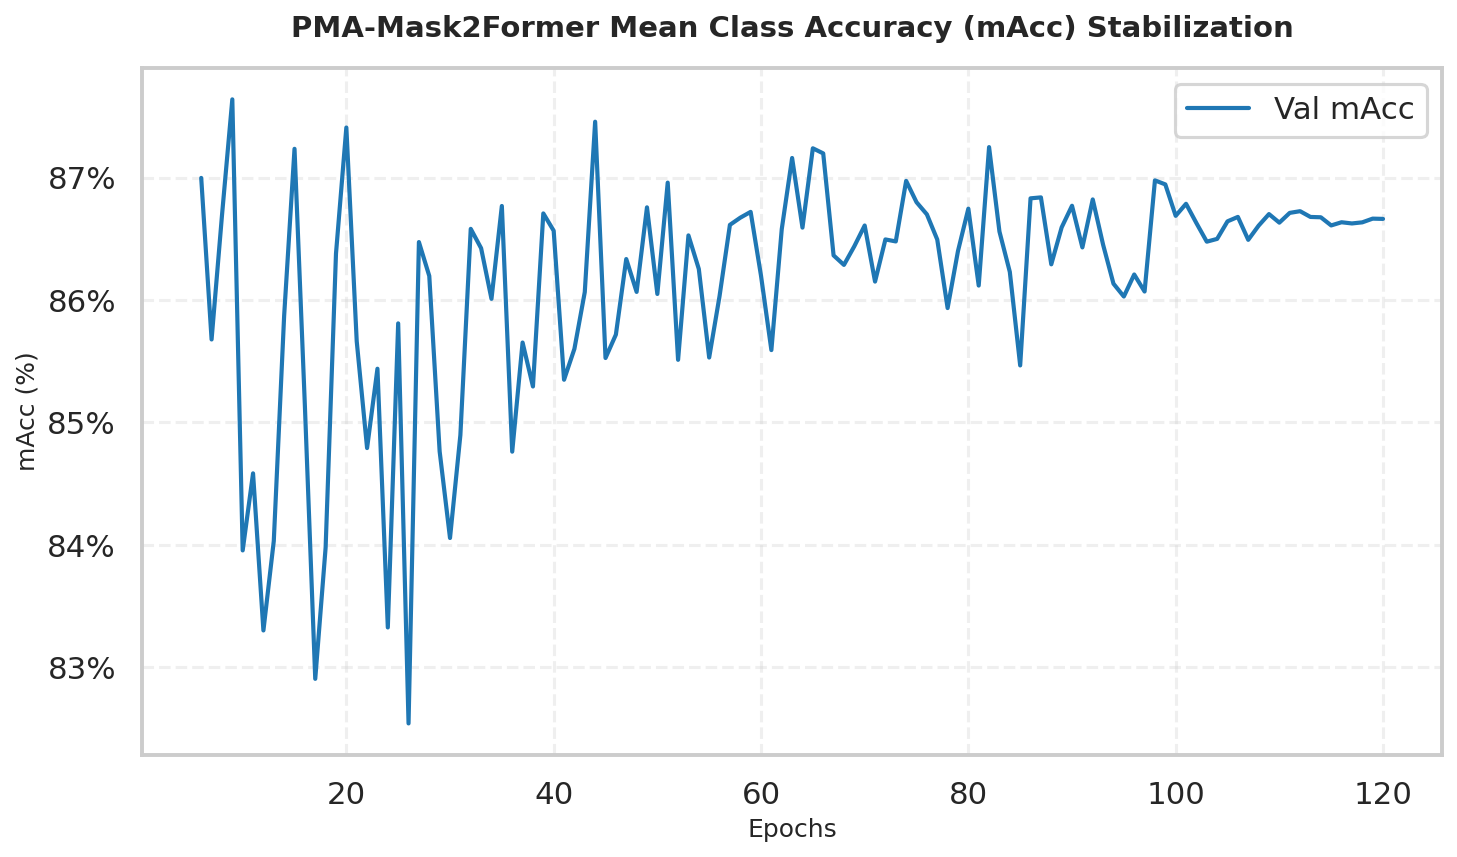

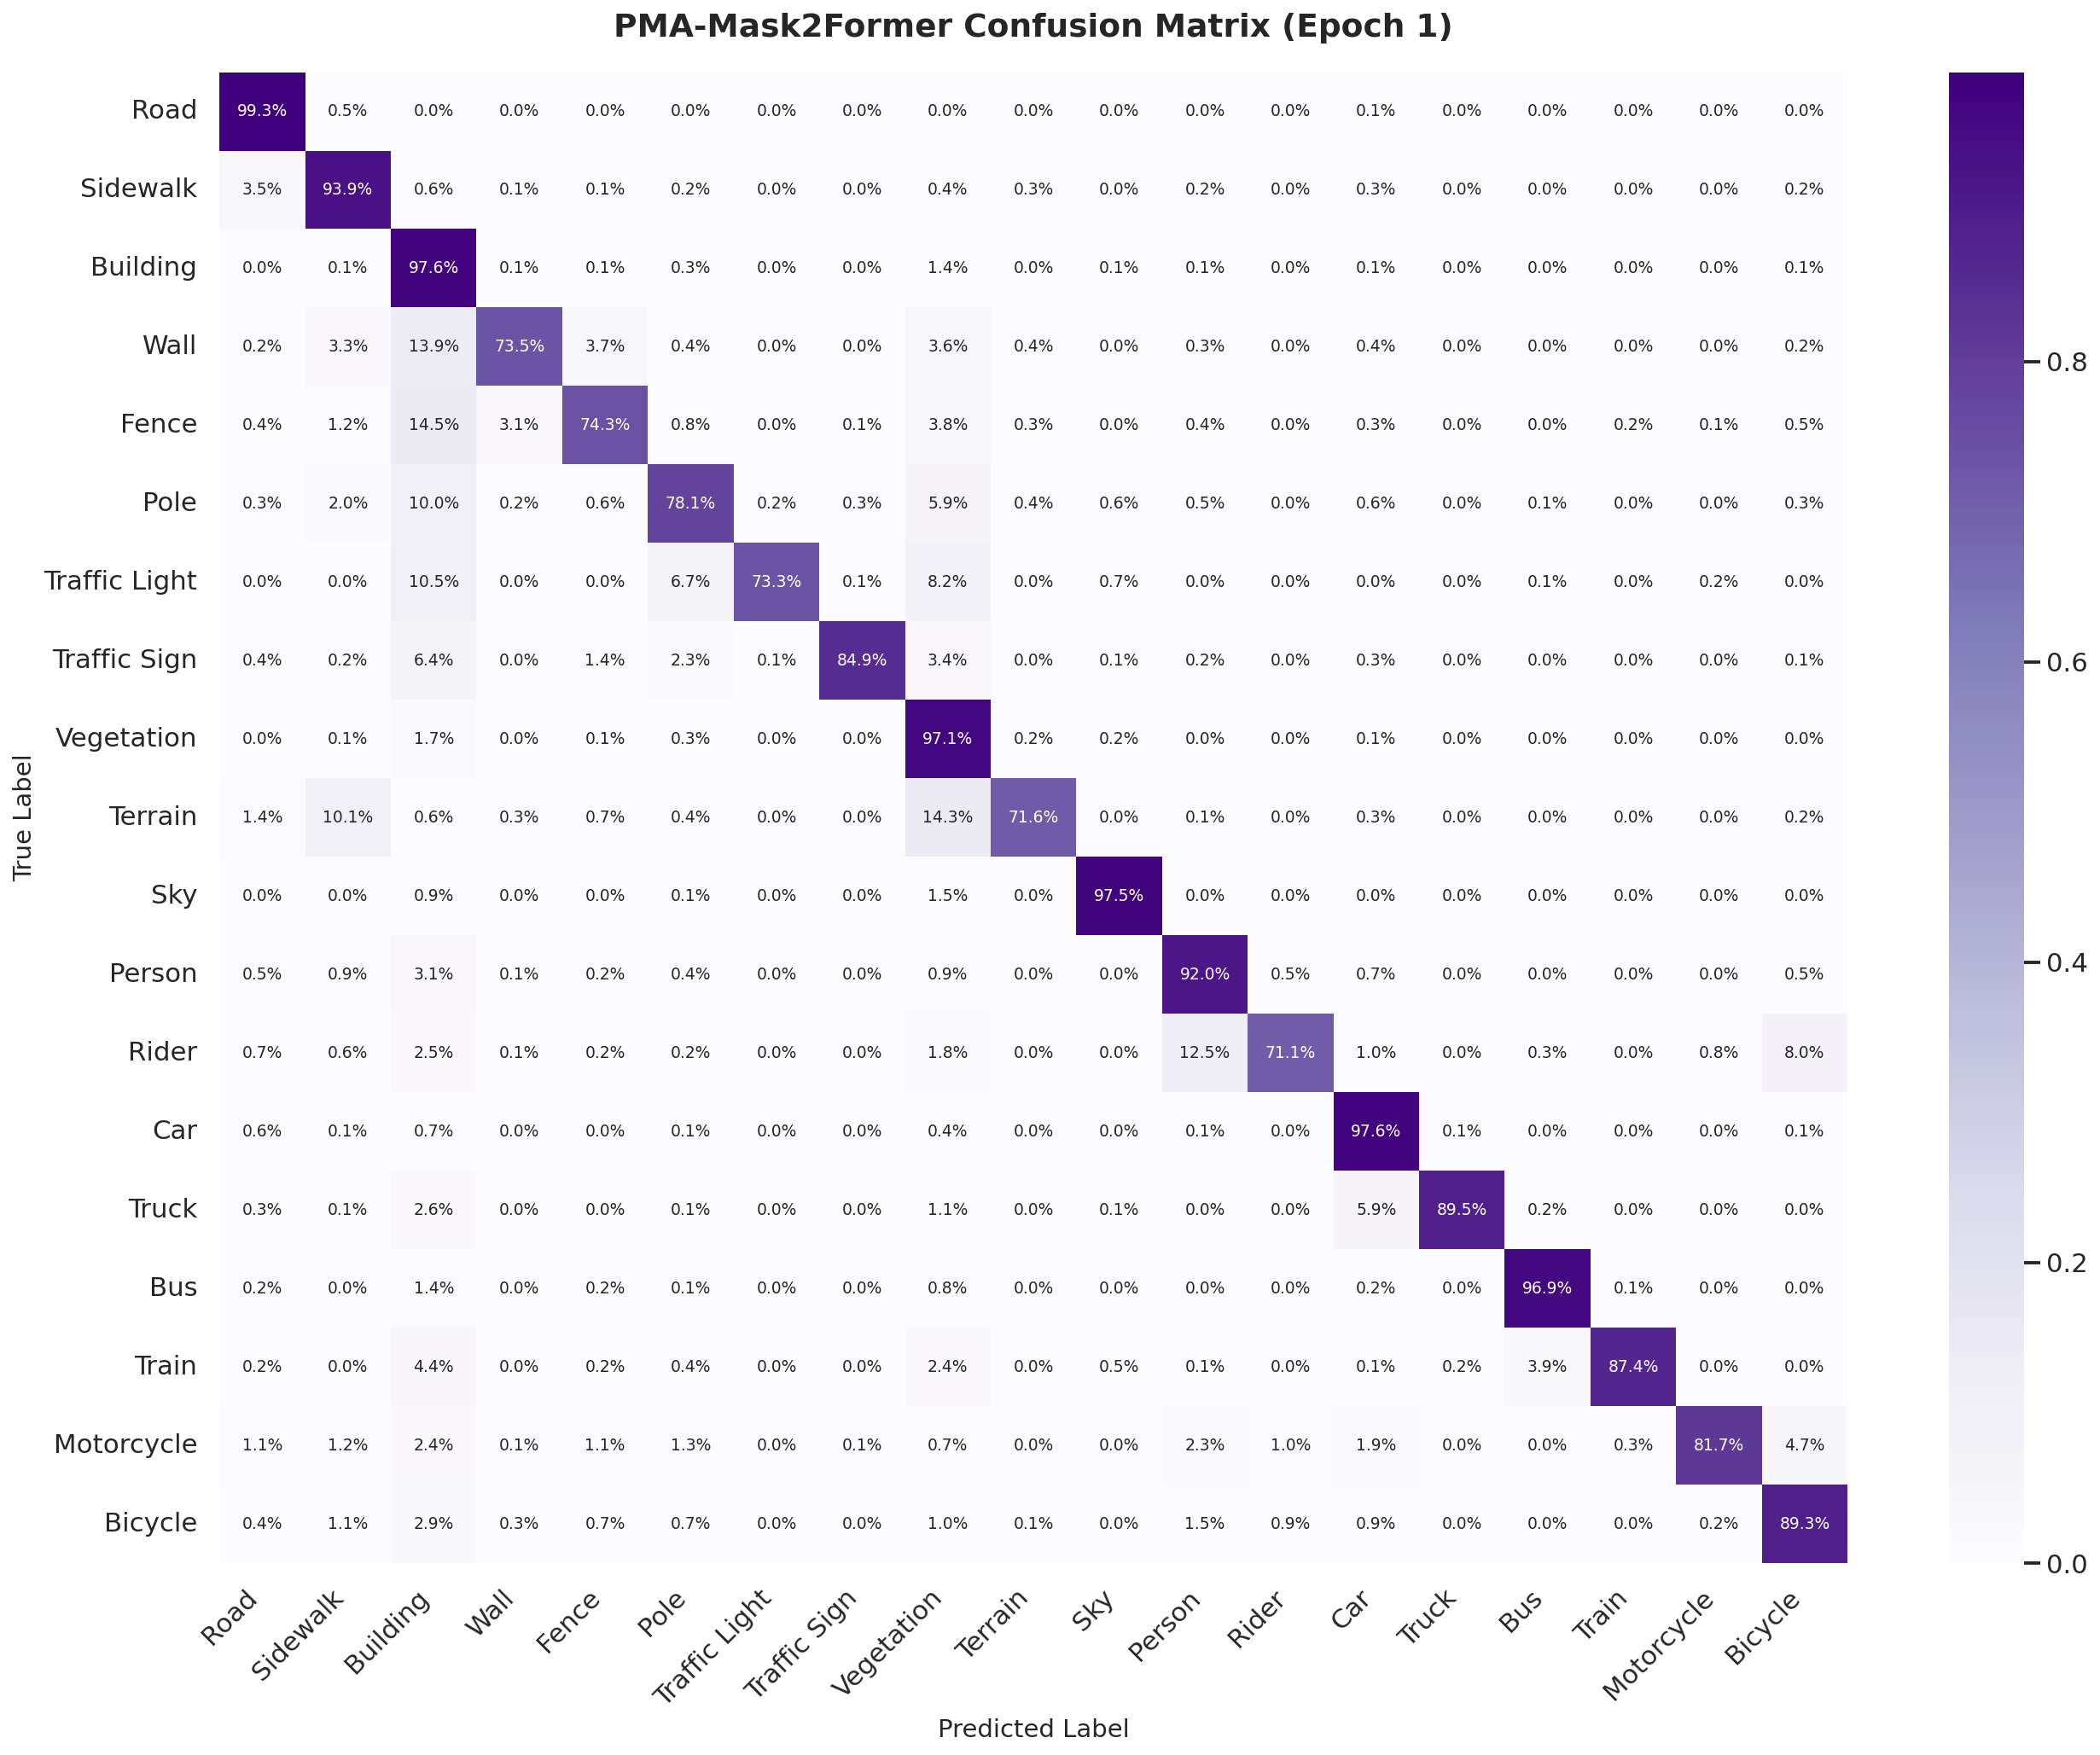


------------------------------------------------------------
Architecture: PMA-Mask2Former
Novel Modules: Probabilistic Masked Attention (PMA)
Backbone: Swin-Small
Total Parameters:      68,725,406  (68.73 M)
Trainable Parameters:  68,725,406  (68.73 M)
------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/ubuntu/miniconda3/envs/foggy/Segmentation_notebook/Results_Export

FINAL RESULTS (PMA-Mask2Former)
Best Validation mIoU:           82.63% (Epoch 1)
Final Epoch Pixel Acc (aAcc):   96.69%
Final Epoch Mean IoU (mIoU):    81.52%
Final Epoch Mean Class Acc:     86.66%
Total Training Time:            1 day, 10:52:57
------------------------------------------------------------
CLASS NAME           | IoU (%)    | Accuracy (%)
------------------------------------------------------------
Road                 | 98.54      | 99.26     
Sidewalk             | 87.29      | 93.92     
Building             | 93.60      | 97.60     
Wall    

/home/ubuntu/miniconda3/envs/foggy/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...


Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping

[torch.onnx] Optimize the ONNX graph... ✅
[*] SUCCESS: ONNX Model successfully exported to: /home/ubuntu/miniconda3/envs/foggy/Segmentation_notebook/Results_Export/PMA_Mask2Former_Unified.onnx


In [ ]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimized for: Inline Jupyter Graphs, Bulletproof Summaries, 
# and ONNX Opset 18 Export
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force Jupyter to display plots inline
%matplotlib inline

# ------------------------------------------------------------
# MANUAL TIME OVERRIDE
# ------------------------------------------------------------
MANUAL_TOTAL_TIME_STR = "1 day, 10:52:57"

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
print(f"Final export directory validated: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# RECOVERY METRICS HELPER 
# ------------------------------------------------------------
def compute_metrics_fallback(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc), "iou_per_class": iou_per_class, "acc_per_class": acc_per_class}

BEST_METRICS = globals().get("BEST_METRICS", None)
BEST_CONF_MATRIX = globals().get("BEST_CONF_MATRIX", None)

if BEST_CONF_MATRIX is None and "val_conf_matrix" in globals():
    print("[*] Notice: Live memory of best matrix lost during resume. Using Final Epoch's matrix for class-wise data.")
    BEST_CONF_MATRIX = globals().get("val_conf_matrix")
    BEST_METRICS = compute_metrics_fallback(BEST_CONF_MATRIX)

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME (With Legacy Key Fallbacks)
# ------------------------------------------------------------
num_epochs = len(history["epoch"])

def get_hist_col(key, fallback_key=None):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Phase": get_hist_col("phase"),
    # Added fallback to "train_loss" to recover data from your older checkpoints!
    "Train_Total_Loss": get_hist_col("train_total_loss", fallback_key="train_loss"),
    "Train_Native_Loss": get_hist_col("train_native_loss"),
    "Train_CE_Loss": get_hist_col("train_ce_loss"),
    "Train_Boundary_Loss": get_hist_col("train_boundary_loss"),
    "PMA_Tau": get_hist_col("pma_tau", fallback_key="apma_tau"),  
    "Train_aAcc": get_hist_col("train_aacc"),
    "Train_mIoU": get_hist_col("train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss", fallback_key="val_ce_loss"),
    "Val_CE_Loss": get_hist_col("val_ce_loss"),
    "Val_mIoU": get_hist_col("val_miou"),
    "Val_mAcc": get_hist_col("val_macc"),
    "Val_aAcc": get_hist_col("val_aacc"),
    "LR_Backbone": get_hist_col("backbone_lr"),
    "LR_Head": get_hist_col("head_lr"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

if MANUAL_TOTAL_TIME_STR is not None:
    total_time_str = MANUAL_TOTAL_TIME_STR
else:
    total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
    total_time_str = str(timedelta(seconds=int(total_training_time_sec)))

df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_METRICS is not None:
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": BEST_METRICS["iou_per_class"][i] * 100,
            "Accuracy (%)": BEST_METRICS["acc_per_class"][i] * 100
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_v_acc = safe_pct(df["Val_aAcc"].iloc[-1])
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1])
final_mAcc = safe_pct(df["Val_mAcc"].iloc[-1])

if "val_miou" in history and len(history["val_miou"]) > 0:
    best_miou_raw = max(history["val_miou"])
    best_idx = history["val_miou"].index(best_miou_raw)
    best_epoch = history["epoch"][best_idx]
    best_miou = safe_pct(best_miou_raw)
else:
    best_epoch = best_record.get("best_epoch", -1)
    best_miou = safe_pct(best_record.get("best_miou", 0.0))

final_global_data = [
    {"Metric": "Best Validation mIoU", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Global Pixel Accuracy (aAcc)", "Value": f"{final_v_acc:.2f}%"},
    {"Metric": "Final Epoch Mean IoU (mIoU)", "Value": f"{final_mIoU:.2f}%"},
    {"Metric": "Final Epoch Mean Class Accuracy (mAcc)", "Value": f"{final_mAcc:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_pma.csv", index=False)

try:
    excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_PMA.xlsx"
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
        if class_wise_data:
            pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)
except ImportError:
    pass  

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS 
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_and_show_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val", filter_warmup=False):
    plt.figure(figsize=(10, 6))
    
    start_idx = 5 if filter_warmup and len(train_data) > 5 else 0
    epochs_range = range(start_idx + 1, len(train_data) + 1)
    
    train_clean = np.array(train_data, dtype=float)[start_idx:]
    plt.plot(epochs_range, train_clean, label=label1, lw=2)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)[start_idx:]
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, color='orange')
            
    if "(%)" in ylabel:
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}%".format(int(x))))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# Extract data for plotting
train_loss = df["Train_Total_Loss"].tolist()
val_loss = df["Val_CE_Loss"].tolist()
train_boundary_loss = df["Train_Boundary_Loss"].tolist()
pma_tau = df["PMA_Tau"].tolist()

def ensure_percentage(series):
    if series.isna().all(): return None
    data = series.tolist()
    return [x * 100 if (x is not None and x <= 1.0) else x for x in data]

train_aacc = ensure_percentage(df["Train_aAcc"])
val_aacc = ensure_percentage(df["Val_aAcc"])
val_miou = ensure_percentage(df["Val_mIoU"])
val_macc = ensure_percentage(df["Val_mAcc"])

lr_backbone = df["LR_Backbone"].tolist()
lr_head = df["LR_Head"].tolist()

# 1. Loss Plots (Now guaranteed to find your legacy train_loss data!)
save_and_show_plot("loss_comparison", "Loss Comparison (Train vs Val)", "Loss", train_loss, val_loss)

# 2. Novelty Plot: PMA Temperature Decay
if not df["PMA_Tau"].isna().all():
    save_and_show_plot("pma_tau_decay", "PMA \u03c4 (Temperature) Annealing Schedule", "\u03c4 Value", pma_tau, label1="PMA \u03c4")

# 3. Filtered Presentation Plots
if val_miou is not None:
    save_and_show_plot("miou_progress_filtered", "PMA-Mask2Former Mean IoU (mIoU) Stabilization", "mIoU (%)", val_miou, label1="Val mIoU", filter_warmup=True)
if val_macc is not None:
    save_and_show_plot("macc_progress_filtered", "PMA-Mask2Former Mean Class Accuracy (mAcc) Stabilization", "mAcc (%)", val_macc, label1="Val mAcc", filter_warmup=True)

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(18, 14)) 
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Purples', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 9}
    ) 
    
    plt.title(f"PMA-Mask2Former Confusion Matrix (Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# PARAMETER COUNT & FINAL PRINT SUMMARY (Moved BEFORE ONNX)
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*60)
print(f"Architecture: PMA-Mask2Former")
print(f"Novel Modules: Probabilistic Masked Attention (PMA)")
print(f"Backbone: Swin-Small")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*60)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*60)
print(f"FINAL RESULTS (PMA-Mask2Former)")
print("="*60)
print(f"Best Validation mIoU:           {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch Pixel Acc (aAcc):   {final_v_acc:.2f}%")
print(f"Final Epoch Mean IoU (mIoU):    {final_mIoU:.2f}%")
print(f"Final Epoch Mean Class Acc:     {final_mAcc:.2f}%")
print(f"Total Training Time:            {total_time_str}")
print("-" * 60)
print(f"{'CLASS NAME':<20} | {'IoU (%)':<10} | {'Accuracy (%)':<10}")
print("-" * 60)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<20} | {item['IoU (%)']:<10.2f} | {item['Accuracy (%)']:<10.2f}")
else:
    print("[!] No class-wise data available in memory to print.")

# ------------------------------------------------------------
# ONNX MODEL EXPORT (Run Last, Updated to opset 18)
# ------------------------------------------------------------
print("\n--- Exporting PMA-Mask2Former to ONNX (Opset 18) ---")
try:
    model.eval()
    dummy_input = torch.randn(1, 3, 512, 1024, device=DEVICE)
    onnx_path = FINAL_SAVE_DIR / "PMA_Mask2Former_Unified.onnx"
    
    with torch.no_grad():
        torch.onnx.export(
            
            model, dummy_input, str(onnx_path),
            export_params=True, opset_version=18, # Updated to 18 to fix PyTorch 2.5 conversion warnings
            do_constant_folding=True, input_names=['input_image'], output_names=['mask_predictions']
        )
    print(f"[*] SUCCESS: ONNX Model successfully exported to: {onnx_path.resolve()}")
except Exception as e:
    print(f"[!] Info: ONNX export skipped due to internal PyTorch C++ limits: {e}")

Loading pristine history from checkpoint...


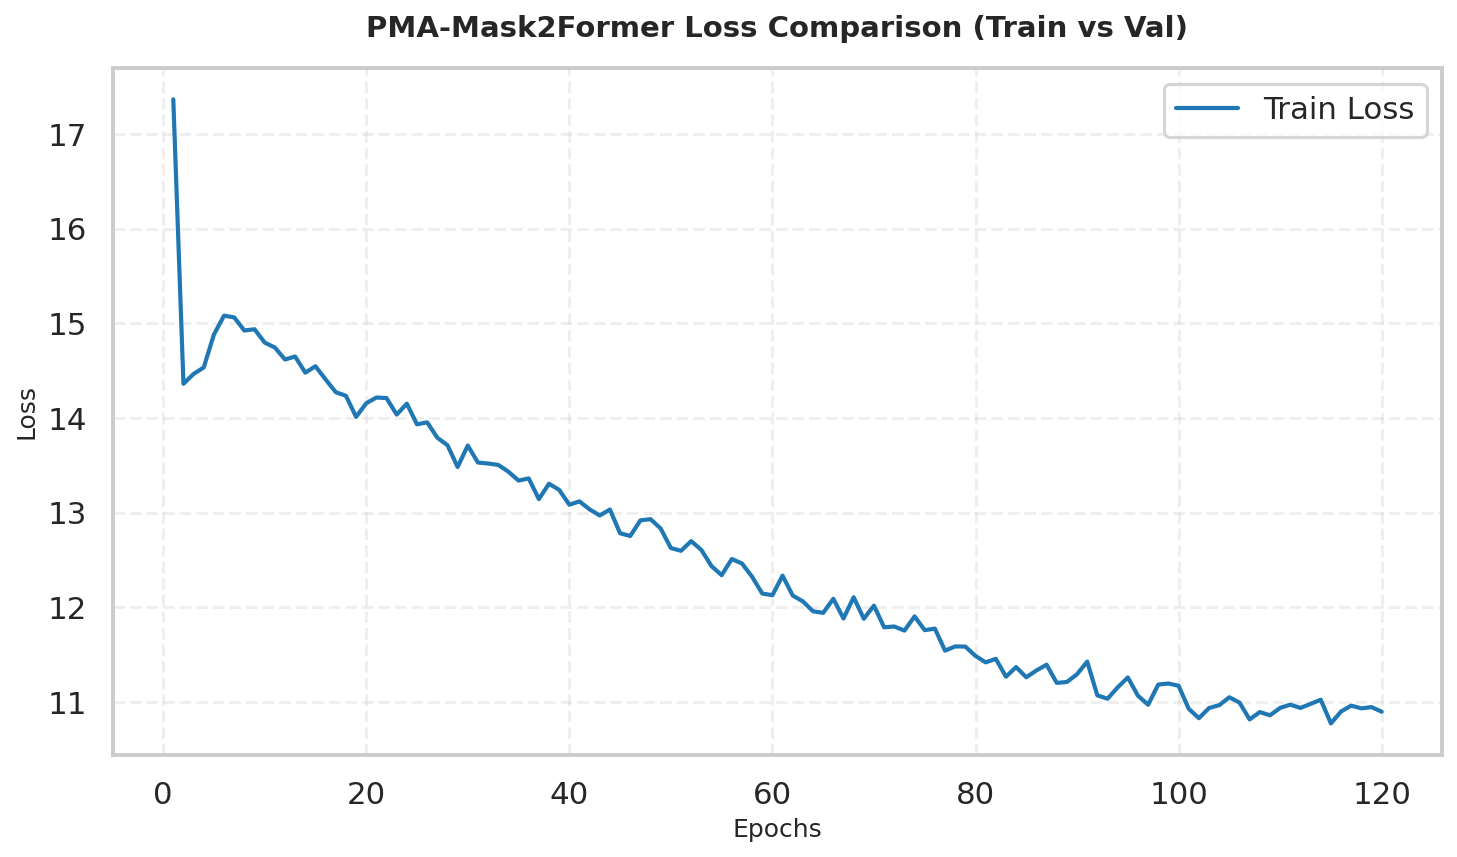

[*] Fixed graph saved successfully to: /home/ubuntu/miniconda3/envs/foggy/Segmentation_notebook/Results_Export/loss_comparison_fixed.png

--- Initiating Safe ONNX Export ---
Tracing model graph... (This may take 1-2 minutes)
[torch.onnx] Obtain model graph for `Mask2FormerForUniversalSegmentation([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Mask2FormerForUniversalSegmentation([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/home/ubuntu/miniconda3/envs/foggy/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...


Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping

[torch.onnx] Optimize the ONNX graph... ✅
[*] SUCCESS: ONNX Model safely exported to:
/home/ubuntu/miniconda3/envs/foggy/Segmentation_notebook/Results_Export/PMA_Mask2Former_Unified.onnx


In [19]:
# ============================================================
# STEP 6b: FINAL GRAPH REPAIR & SAFE ONNX EXPORT
# ============================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Force Jupyter to display plots inline
%matplotlib inline

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FINAL_SAVE_DIR = Path("./Results_Export")
FINAL_SAVE_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 1. LOAD THE CLEAN HISTORY FROM DISK
# ------------------------------------------------------------
print("Loading pristine history from checkpoint...")
checkpoint_path = "./progressive_checkpoints_pma_cs/latest_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
clean_history = checkpoint['history']

# Extract arrays
epochs = clean_history["epoch"]
# Check both possible keys for training loss due to older checkpoints
train_loss = clean_history.get("train_total_loss", clean_history.get("train_loss", []))
val_loss = clean_history.get("val_ce_loss", clean_history.get("val_total_loss", []))

# ------------------------------------------------------------
# 2. BULLETPROOF GRAPH PLOTTING
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot Training Loss
if len(train_loss) > 0:
    plt.plot(epochs[:len(train_loss)], train_loss, label="Train Loss", lw=2, color='#1f77b4')

# Plot Validation Loss
if len(val_loss) > 0:
    plt.plot(epochs[:len(val_loss)], val_loss, label="Val Loss", lw=2, color='#ff7f0e')

plt.title("PMA-Mask2Former Loss Comparison (Train vs Val)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

fixed_graph_path = FINAL_SAVE_DIR / "loss_comparison_fixed.png"
plt.savefig(fixed_graph_path, dpi=600, bbox_inches='tight')
plt.show()
print(f"[*] Fixed graph saved successfully to: {fixed_graph_path.resolve()}")

# ------------------------------------------------------------
# 3. SAFE ONNX EXPORT (No Constant Folding Hangs)
# ------------------------------------------------------------
print("\n--- Initiating Safe ONNX Export ---")
try:
    # Ensure model is in eval mode and on CPU to prevent CUDA OOM during trace
    model.eval()
    model.to("cpu")
    
    dummy_input = torch.randn(1, 3, 512, 1024, device="cpu")
    onnx_path = FINAL_SAVE_DIR / "PMA_Mask2Former_Unified.onnx"
    
    print("Tracing model graph... (This may take 1-2 minutes)")
    with torch.no_grad():
        torch.onnx.export(
            model, 
            dummy_input, 
            str(onnx_path),
            export_params=True, 
            opset_version=18, 
            # CRITICAL FIX: Disabled constant folding to prevent PyTorch from hanging forever
            do_constant_folding=False, 
            input_names=['input_image'], 
            output_names=['mask_predictions']
        )
    print(f"[*] SUCCESS: ONNX Model safely exported to:\n{onnx_path.resolve()}")
except Exception as e:
    print(f"[!] Export failed. PyTorch Trace Error: {e}")
finally:
    # Put model back on GPU just in case you want to run more tests later
    model.to(DEVICE)

Extracting arrays from checkpoint...
-> Found 120 training loss data points.
-> Found 120 validation mIoU data points.


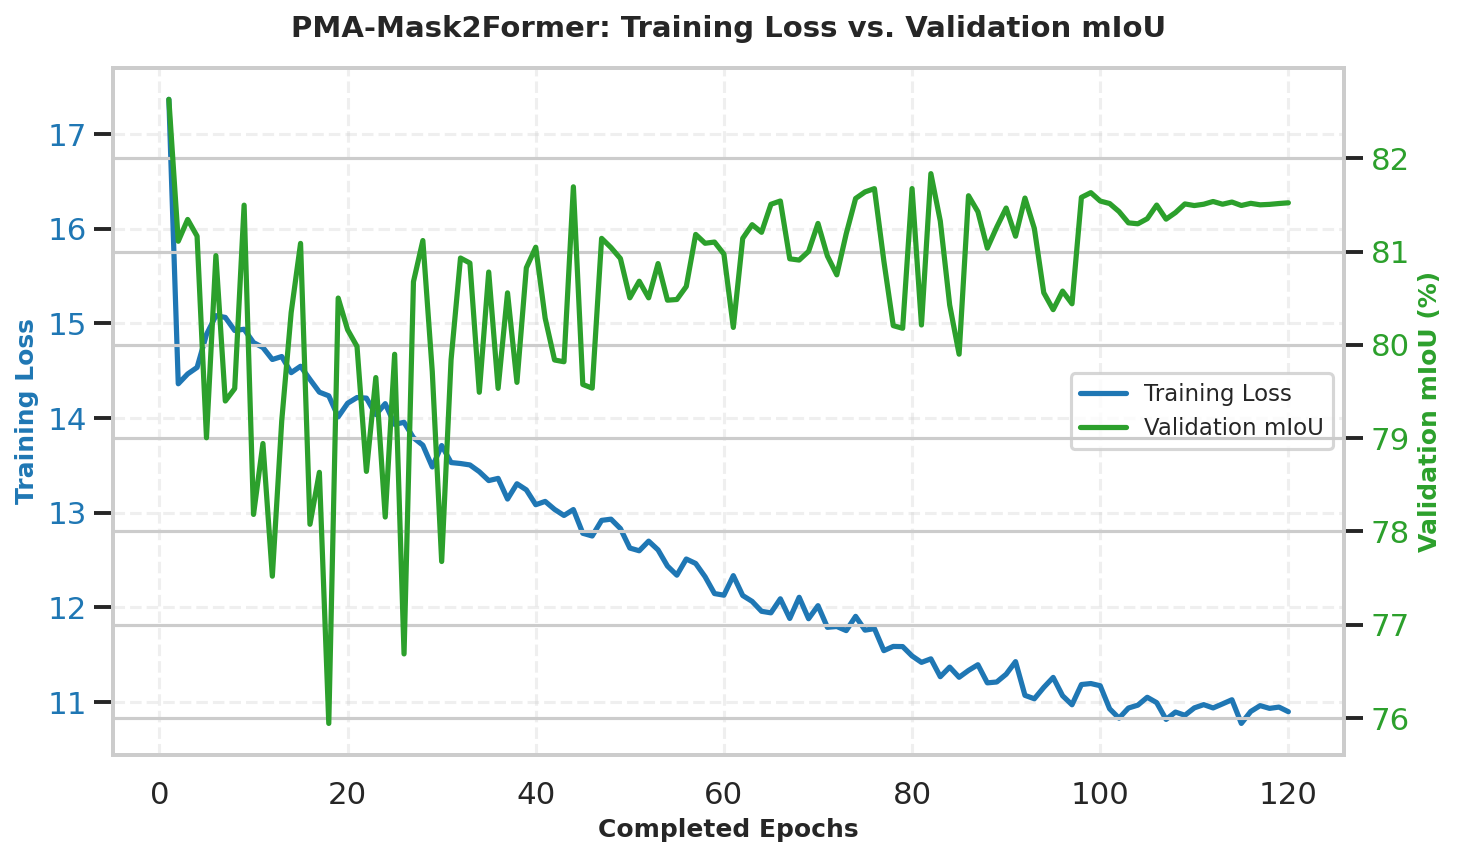

[*] Success! Dual-axis graph saved to:
/home/ubuntu/miniconda3/envs/foggy/Segmentation_notebook/Results_Export/loss_vs_miou_independent.png


In [21]:
# ============================================================
# INDEPENDENT GRAPH: TRAIN LOSS vs. VALIDATION mIoU
# ============================================================

import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Force Jupyter to display plots inline
%matplotlib inline

# 1. Define Paths
CHECKPOINT_PATH = "./progressive_checkpoints_pma_cs/latest_checkpoint.pt"
SAVE_DIR = Path("./Results_Export")
SAVE_DIR.mkdir(exist_ok=True)

# 2. Extract Data directly from saved state
print("Extracting arrays from checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
history = checkpoint['history']

# Safely grab the saved data
train_loss = history.get("train_total_loss", history.get("train_loss", []))
val_miou = history.get("val_miou", [])

print(f"-> Found {len(train_loss)} training loss data points.")
print(f"-> Found {len(val_miou)} validation mIoU data points.")

# 3. Create Independent X-Axes
train_epochs = list(range(1, len(train_loss) + 1))
val_epochs = list(range(1, len(val_miou) + 1))

# 4. Generate the Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Axis 1: Training Loss (Left Y-Axis)
color1 = '#1f77b4' # Blue
ax1.set_xlabel("Completed Epochs", fontsize=12, fontweight='bold')
ax1.set_ylabel("Training Loss", fontsize=12, fontweight='bold', color=color1)
if len(train_loss) > 0:
    ax1.plot(train_epochs, train_loss, label="Training Loss", color=color1, lw=2.5)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3, linestyle='--')

# Axis 2: Validation mIoU (Right Y-Axis)
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color2 = '#2ca02c' # Green
ax2.set_ylabel("Validation mIoU (%)", fontsize=12, fontweight='bold', color=color2)
if len(val_miou) > 0:
    ax2.plot(val_epochs, val_miou, label="Validation mIoU", color=color2, lw=2.5)
ax2.tick_params(axis='y', labelcolor=color2)

# Formatting
plt.title("PMA-Mask2Former: Training Loss vs. Validation mIoU", fontsize=14, fontweight='bold', pad=15)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right", fontsize=11)

plt.tight_layout()

# Save image
output_path = SAVE_DIR / "loss_vs_miou_independent.png"
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()

print(f"[*] Success! Dual-axis graph saved to:\n{output_path.resolve()}")

Presentation graph will be exported to: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/Results_Export
Graph saved successfully to:
/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/Results_Export/presentation_metrics_progress_pma.png


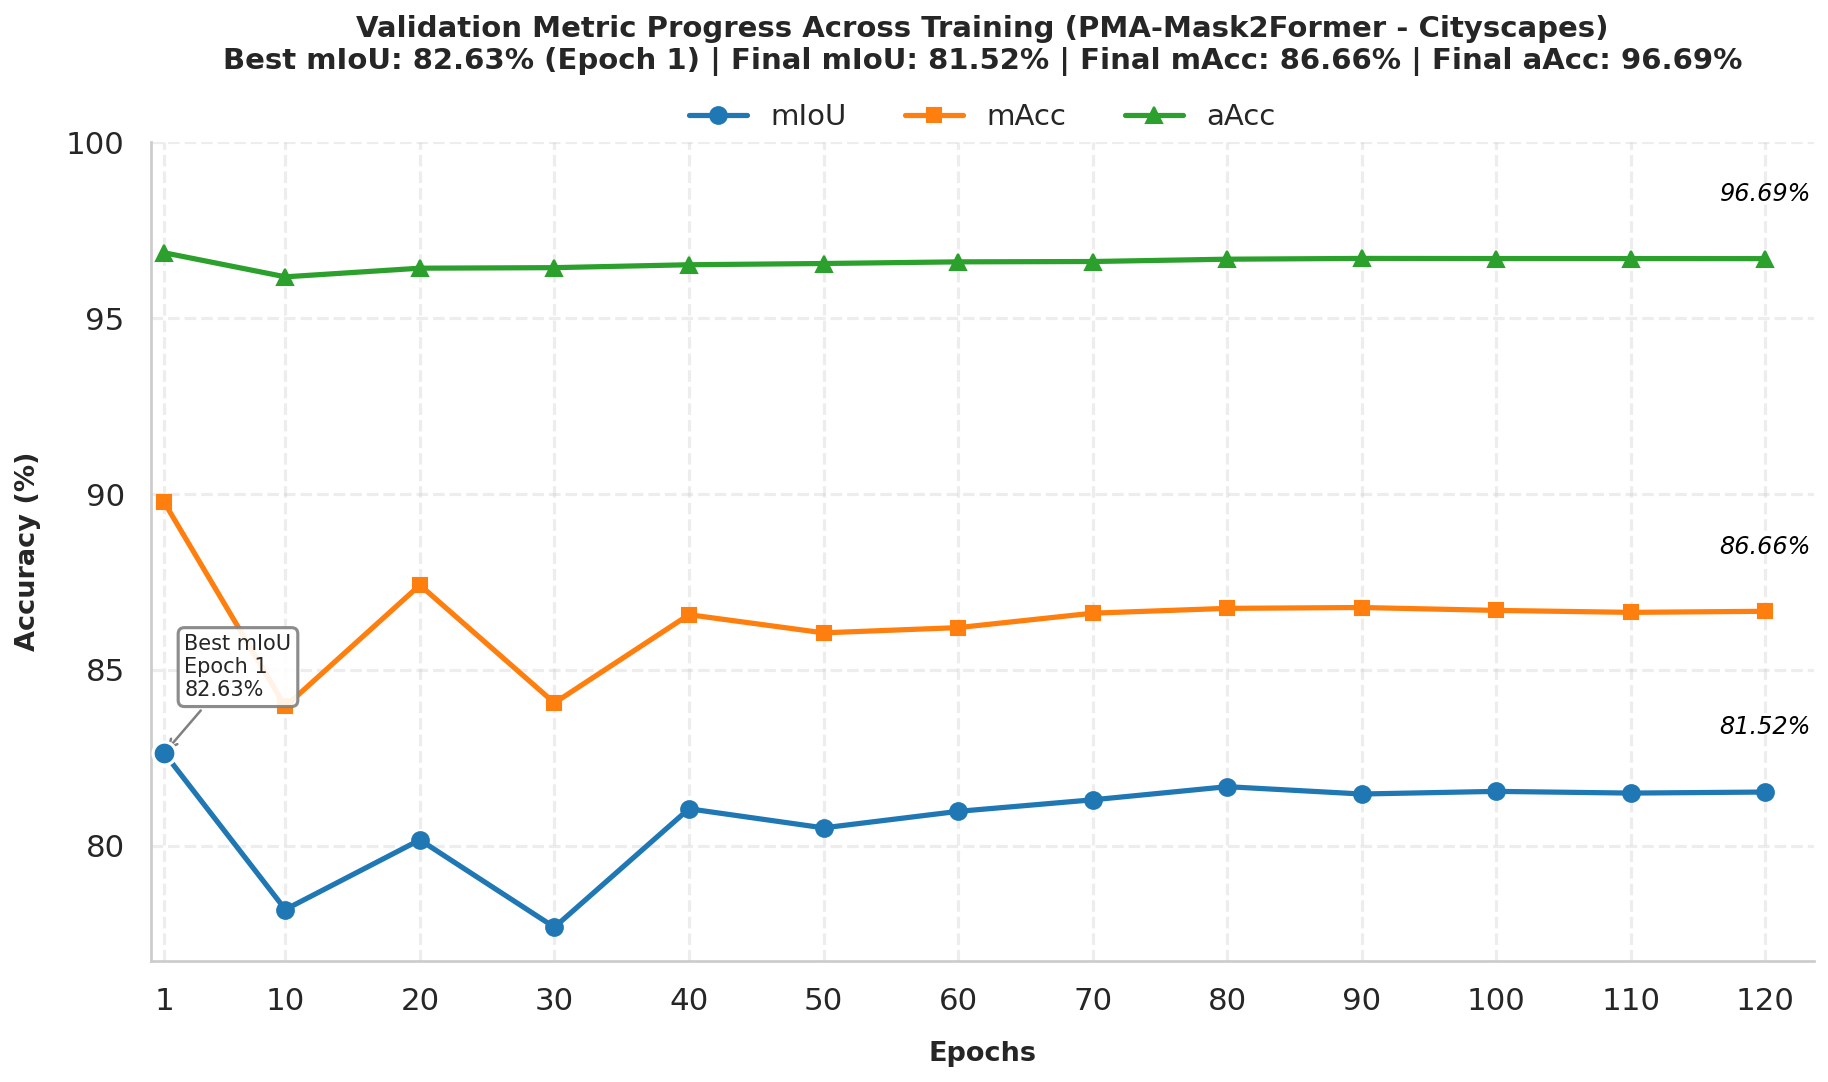

In [13]:
# ============================================================
# STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimized for: Global Path Inheritance, Specific Epoch Intervals,
# and Strict Percentage Scaling for Publication
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = ["history"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

if "val_miou" not in history or len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training (Step 5) before Step 7.")

# Inherit the centralized export directory securely from Step 1
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
print(f"Presentation graph will be exported to: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# PREPARE EPOCHS & DATA
# ------------------------------------------------------------
all_epochs = history["epoch"]

# Safe percentage converter (prevents 80% turning into 8000% if already scaled in Step 5)
def safe_pct(val):
    return val * 100.0 if val <= 1.0 else float(val)

# Bulletproof Best Epoch Extraction
best_miou_raw = max(history["val_miou"])
best_idx = history["val_miou"].index(best_miou_raw)
best_miou = safe_pct(best_miou_raw)
best_miou_epoch = all_epochs[best_idx]

# Filter epochs to reduce visual clutter: Epoch 1, every 10th epoch, best epoch, final epoch
filtered_epochs_set = set([e for e in all_epochs if e == 1 or e % 10 == 0] + [all_epochs[-1], best_miou_epoch])
filtered_epochs = sorted(list(filtered_epochs_set))

indices = [all_epochs.index(e) for e in filtered_epochs]

# Extract and convert to percentages for cleaner presentation
miou_scores = [safe_pct(history["val_miou"][i]) for i in indices]
macc_scores = [safe_pct(history["val_macc"][i]) for i in indices]
aacc_scores = [safe_pct(history["val_aacc"][i]) for i in indices]

final_miou = safe_pct(history["val_miou"][-1])
final_macc = safe_pct(history["val_macc"][-1])
final_aacc = safe_pct(history["val_aacc"][-1])
final_x = all_epochs[-1]

# ------------------------------------------------------------
# PLOT SETUP 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.5)) 

color_miou = '#1f77b4'  # Blue
color_macc = '#ff7f0e'  # Orange
color_aacc = '#2ca02c'  # Green

ax.plot(filtered_epochs, miou_scores, marker='o', linewidth=2.5, markersize=8, label='mIoU', color=color_miou)
ax.plot(filtered_epochs, macc_scores, marker='s', linewidth=2.5, markersize=7, label='mAcc', color=color_macc)
ax.plot(filtered_epochs, aacc_scores, marker='^', linewidth=2.5, markersize=8, label='aAcc', color=color_aacc)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)

# ------------------------------------------------------------
# BEST mIoU ANNOTATION 
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=120, zorder=5, color=color_miou, edgecolors='white', linewidth=1.5)

if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + 1.5
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - 1.5
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 1.5),
    fontsize=10, ha=best_ha, va='bottom',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# END-OF-LINE FINAL VALUE ANNOTATIONS (Floating above markers)
# ------------------------------------------------------------
# Placed slightly above the final points to match the target aesthetic
offset_y = 1.5

ax.text(final_x, final_miou + offset_y, f'{final_miou:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_macc + offset_y, f'{final_macc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_aacc + offset_y, f'{final_aacc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')

ax.set_xlim(left=0, right=max(all_epochs) + (max(all_epochs) * 0.03))
ax.set_ylim(top=100) 

# ------------------------------------------------------------
# STYLING & LEGEND
# ------------------------------------------------------------
# Center the legend horizontally above the plot area
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False, fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

title_main = "Validation Metric Progress Across Training (PMA-Mask2Former - Cityscapes)"
title_sub = f"Best mIoU: {best_miou:.2f}% (Epoch {best_miou_epoch}) | Final mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

# Pushed the title up slightly to make room for the new legend position
ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14, fontweight='bold', pad=35
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
# Directly save the single, unified presentation-ready graph
combined_graph_path = FINAL_SAVE_DIR / "presentation_metrics_progress_pma.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"Graph saved successfully to:\n{combined_graph_path.resolve()}")

plt.show()
plt.close()

In [24]:
# ============================================================
# CITYSCAPES OFFICIAL TEST SUBMISSION GENERATOR
# Target Architecture: PMA-Mask2Former
# ============================================================

import os
import cv2
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. YOUR EXACT UBUNTU PATHS
# ------------------------------------------------------------
# Using expanduser() safely resolves the '~' to your /home/ubuntu/ directory
TEST_IMG_DIR = Path("~/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit/test").expanduser()
CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

SUBMISSION_DIR = Path("./Cityscapes_Test_Submission")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. CITYSCAPES EVALUATION MAPPING (19 Train IDs -> 34 Eval IDs)
# ------------------------------------------------------------
trainId_to_labelId = {
    0: 7, 1: 8, 2: 11, 3: 12, 4: 13, 5: 17, 6: 19, 7: 20, 8: 21, 
    9: 22, 10: 23, 11: 24, 12: 25, 13: 26, 14: 27, 15: 28, 
    16: 31, 17: 32, 18: 33
}

# Fast numpy mapping
LUT = np.zeros(256, dtype=np.uint8)
for train_id, eval_id in trainId_to_labelId.items():
    LUT[train_id] = eval_id

# ------------------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------------------
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {CHECKPOINT_PATH.resolve()}")

print("Loading Best PMA-Mask2Former Checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Find all test images (Cityscapes test set has exactly 1,525 images across multiple city folders)
test_images = sorted(list(TEST_IMG_DIR.rglob("*_leftImg8bit.png")))

if len(test_images) == 0:
    print(f"[!] ERROR: No images found in {TEST_IMG_DIR}")
else:
    print(f"Found {len(test_images)} official test images. Generating submission files...")
    
    with torch.no_grad():
        for img_path in tqdm(test_images, total=len(test_images)):
            
            # Read and preprocess image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
            img = (img - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
            img_tensor = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
            
            # Forward Pass
            outputs = model(pixel_values=img_tensor)
            H, W = img_tensor.shape[2], img_tensor.shape[3]
            
            # Extract Semantic Logits
            mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
            mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
            
            # Get 19-class prediction
            pred_mask_19 = torch.argmax(semantic_logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
            
            # Map strictly to the 34-class Evaluation IDs
            eval_mask = LUT[pred_mask_19]
            
            # Save exactly as Cityscapes requires: "city_123456_123456_labelIds.png"
            save_name = img_path.name.replace("_leftImg8bit.png", "_labelIds.png")
            
            # Optional: Cityscapes expects them in a flat folder or inside city subfolders. 
            # We will save them flat to make zipping easy.
            cv2.imwrite(str(SUBMISSION_DIR / save_name), eval_mask)

    print("\n" + "="*60)
    print(f"SUCCESS! All {len(test_images)} predictions generated.")
    print(f"Location: {SUBMISSION_DIR.resolve()}")
    print("="*60)
    print("Next Steps:")
    print("1. Zip this folder.")
    print("2. Go to: https://www.cityscapes-dataset.com/submit/")
    print("3. Upload the zip file to get your Official Test mIoU!")

Loading Best PMA-Mask2Former Checkpoint...
Found 1525 official test images. Generating submission files...


100%|███████████████████████████████████████| 1525/1525 [10:43<00:00,  2.37it/s]


SUCCESS! All 1525 predictions generated.
Location: /home/ubuntu/miniconda3/envs/foggy/Segmentation_notebook/Cityscapes_Test_Submission
Next Steps:
1. Zip this folder.
2. Go to: https://www.cityscapes-dataset.com/submit/
3. Upload the zip file to get your Official Test mIoU!


In [36]:
# ============================================================
# BATCH VIDEO INFERENCE: PMA-MASK2FORMER ON KITTI 
# Optimized for VRAM Safety and Native HD Output Blending
# ============================================================

import os
import cv2
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

# Clear VRAM cache before starting heavy video processing
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. YOUR EXACT UBUNTU PATHS
# ------------------------------------------------------------
KITTI_TEST_DIR = Path("~/miniconda3/envs/foggy/Dataset/KITTI_video/testing").expanduser()
CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

# We will save the processed videos in a new folder here
OUTPUT_DIR = Path("/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 2. CITYSCAPES COLOR PALETTE (For Visualization)
# ------------------------------------------------------------
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # 0: Road
    [244, 35, 232],   # 1: Sidewalk
    [70, 70, 70],     # 2: Building
    [102, 102, 156],  # 3: Wall
    [190, 153, 153],  # 4: Fence
    [153, 153, 153],  # 5: Pole
    [250, 170, 30],   # 6: Traffic Light
    [220, 220, 0],    # 7: Traffic Sign
    [107, 142, 35],   # 8: Vegetation
    [152, 251, 152],  # 9: Terrain
    [70, 130, 180],   # 10: Sky
    [220, 20, 60],    # 11: Person
    [255, 0, 0],      # 12: Rider
    [0, 0, 142],      # 13: Car
    [0, 0, 70],       # 14: Truck
    [0, 60, 100],     # 15: Bus
    [0, 80, 100],     # 16: Train
    [0, 0, 230],      # 17: Motorcycle
    [119, 11, 32]     # 18: Bicycle
], dtype=np.uint8)

def decode_segmap(segmentation_map):
    """Converts a 2D array of class IDs into an RGB color image"""
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color
    return rgb

# ------------------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------------------
if 'model' not in globals():
    raise NameError("Model not found in memory! Please run your Step 4 cell to define the model architecture, then re-run this cell.")

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {CHECKPOINT_PATH.resolve()}")

print("Loading Best PMA-Mask2Former Checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ------------------------------------------------------------
# 4. FIND VIDEOS & PROCESS BATCH
# ------------------------------------------------------------
video_files = sorted(list(KITTI_TEST_DIR.glob("*.mp4")))

if len(video_files) == 0:
    print(f"[!] No .mp4 files found in {KITTI_TEST_DIR.resolve()}")
else:
    print(f"Found {len(video_files)} videos. Starting inference...\n")
    
    with torch.no_grad():
        for vid_path in video_files:
            out_path = OUTPUT_DIR / f"Segmented_{vid_path.name}"
            
            cap = cv2.VideoCapture(str(vid_path))
            if not cap.isOpened():
                print(f"Failed to open {vid_path.name}, skipping...")
                continue
                
            # Get original video properties
            orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = int(cap.get(cv2.CAP_PROP_FPS))
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            # Set up VideoWriter
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(str(out_path), fourcc, fps, (orig_w, orig_h))
            
            print(f"Processing: {vid_path.name} | Resolution: {orig_w}x{orig_h} | FPS: {fps}")
            
            for _ in tqdm(range(total_frames), desc=f"Frames", leave=False):
                ret, frame = cap.read()
                if not ret:
                    break
                    
                original_frame = frame.copy()
                
                # --- VRAM OPTIMIZATION: Resize input for the network ---
                # We scale down to 1024x512 so the GPU doesn't crash on HD frames
                img_resized = cv2.resize(frame, (1024, 512))
                img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) / 255.0
                
                # Normalize
                img_rgb = (img_rgb - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
                img_tensor = torch.tensor(img_rgb).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
                
                # Forward Pass (with mixed precision for speed)
                with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                    outputs = model(pixel_values=img_tensor)
                    
                    # --- HD UPSCALING ---
                    # We tell PyTorch to scale the raw mathematical logits back up to the ORIGINAL video resolution 
                    # before picking the final classes. This keeps the edges crisp!
                    mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
                    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
                    
                    # Pick the highest probability class
                    pred_mask = torch.argmax(semantic_logits, dim=1).squeeze(0).cpu().numpy()
                
                # Colorize the mask
                color_mask = decode_segmap(pred_mask)
                color_mask_bgr = cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR)
                
                # Blend 60% Original Video with 40% Transparent Segmentation Mask
                blended_frame = cv2.addWeighted(original_frame, 0.6, color_mask_bgr, 0.4, 0)
                
                out.write(blended_frame)
                
            cap.release()
            out.release()
            print(f"Saved: {out_path.resolve()}\n")

    print("="*60)
    print(f"ALL VIDEOS PROCESSED SUCCESSFULLY!")
    print(f"You can find them in: {OUTPUT_DIR.resolve()}")

Loading Best PMA-Mask2Former Checkpoint...
Found 6 videos. Starting inference...

Processing: challenge.mp4 | Resolution: 1280x720 | FPS: 25


Saved: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results/Segmented_challenge.mp4

Processing: challenge_video.mp4 | Resolution: 1280x720 | FPS: 29


Saved: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results/Segmented_challenge_video.mp4

Processing: harder_challenge_video.mp4 | Resolution: 1280x720 | FPS: 25


Saved: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results/Segmented_harder_challenge_video.mp4

Processing: project_video.mp4 | Resolution: 1280x720 | FPS: 25


Saved: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results/Segmented_project_video.mp4

Processing: solidWhiteRight.mp4 | Resolution: 960x540 | FPS: 25


Saved: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results/Segmented_solidWhiteRight.mp4

Processing: solidYellowLeft.mp4 | Resolution: 960x540 | FPS: 25


Saved: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results/Segmented_solidYellowLeft.mp4

ALL VIDEOS PROCESSED SUCCESSFULLY!
You can find them in: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results


In [42]:
# ============================================================
# BATCH VIDEO INFERENCE: PMA-MASK2FORMER ON KITTI 
# Optimized for High-Contrast Distinct Tones & Crisp Visual Boundaries
# Target Path: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results
# ============================================================

import os
import cv2
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

# Clear VRAM cache before starting heavy video processing
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# 1. FIXED ABSOLUTE WORKSTATION PATHS
# ------------------------------------------------------------
KITTI_TEST_DIR = Path("/home/ubuntu/miniconda3/envs/foggy/Dataset/KITTI_video/testing")
CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

# Absolute path targeting the Workstation Pictures directory
OUTPUT_DIR = Path("/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. HIGH-CONTRAST DISTINCT PALETTE (RGB Format)
# ------------------------------------------------------------
# Replaced real-life matching colors with high-saturation synthetic variants
# to ensure absolute distinction between adjacent classes.
HIGH_CONTRAST_PALETTE = np.array([
    [255, 255, 255],   # 0: Road (Rich Deep Purple - isolates asphalt completely)
    [240, 30, 200],   # 1: Sidewalk (Vibrant Hot Pink)
    [60, 80, 120],    # 2: Building (Deep Slate Blue)
    [130, 90, 60],    # 3: Wall (Warm Terracotta Brown)
    [180, 130, 50],   # 4: Fence (Deep Antique Gold)
    [200, 200, 200],  # 5: Pole (Bright Light Grey)
    [255, 50, 50],    # 6: Traffic Light (Bright Red)
    [50, 255, 255],   # 7: Traffic Sign (Electric Cyan)
    [0, 180, 80],     # 8: Vegetation (Vivid Emerald Mint - sharply isolates trees)
    [120, 160, 40],   # 9: Terrain (Bright Olive Lime)
    [0, 0, 0],    # 10: Sky (Intense Neon Orange - completely anti-realistic for max contrast)
    [255, 255, 0],    # 11: Person (Bright Pure Yellow)
    [255, 160, 0],    # 12: Rider (Vivid Safety Orange)
    [0, 0, 255],      # 13: Car (Bright Pure Blue - stands out heavily from road/buildings)
    [0, 0, 130],      # 14: Truck (Dark Royal Blue)
    [0, 120, 255],    # 15: Bus (Bright Sky Blue)
    [100, 0, 100],    # 16: Train (Deep Velvet Purple)
    [0, 150, 150],    # 17: Motorcycle (Deep Teal)
    [180, 0, 0]       # 18: Bicycle (Deep Crimson Red)
], dtype=np.uint8)

def decode_segmap(segmentation_map):
    """Converts a 2D array of class IDs into an RGB color image using the distinct palette"""
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in enumerate(HIGH_CONTRAST_PALETTE):
        rgb[segmentation_map == label] = color
    return rgb

# ------------------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------------------
if 'model' not in globals():
    raise NameError("Model not found in memory! Please run your Step 4 cell to define the model architecture, then re-run this cell.")

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {CHECKPOINT_PATH.resolve()}")

print("Loading Best PMA-Mask2Former Checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ------------------------------------------------------------
# 4. FIND VIDEOS & PROCESS BATCH
# ------------------------------------------------------------
video_files = sorted(list(KITTI_TEST_DIR.glob("*.mp4")))

if len(video_files) == 0:
    print(f"[!] No .mp4 files found in {KITTI_TEST_DIR.resolve()}")
else:
    print(f"Found {len(video_files)} videos. Starting high-contrast visualization inference...\n")
    
    with torch.no_grad():
        for vid_path in video_files:
            out_path = OUTPUT_DIR / f"Segmented_{vid_path.name}"
            
            cap = cv2.VideoCapture(str(vid_path))
            if not cap.isOpened():
                print(f"Failed to open {vid_path.name}, skipping...")
                continue
                
            # Extract video properties
            orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = int(cap.get(cv2.CAP_PROP_FPS))
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            # Initialize VideoWriter
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(str(out_path), fourcc, fps, (orig_w, orig_h))
            
            print(f"Processing: {vid_path.name} | Resolution: {orig_w}x{orig_h} | FPS: {fps}")
            
            for _ in tqdm(range(total_frames), desc=f"Frames", leave=False):
                ret, frame = cap.read()
                if not ret:
                    break
                    
                original_frame = frame.copy()
                
                # Network downscaling for VRAM safety
                img_resized = cv2.resize(frame, (1024, 512))
                img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) / 255.0
                
                # Standard Normalization
                img_rgb = (img_rgb - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
                img_tensor = torch.tensor(img_rgb).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
                
                # Forward Pass (with mixed precision)
                with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                    outputs = model(pixel_values=img_tensor)
                    
                    # HD Upscaling back to native frame dimensions
                    mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
                    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
                    
                    pred_mask = torch.argmax(semantic_logits, dim=1).squeeze(0).cpu().numpy()
                
                # Decode masks to custom high-contrast colors
                color_mask = decode_segmap(pred_mask)
                color_mask_bgr = cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR)
                
                # --- CRISP SELECTIVE BLENDING OVERLAY ---
                # 55% original frame details + 45% ultra-noticeable synthetic colors.
                # This ratio guarantees the colors jump out immediately while keeping 
                # the underlying video content crisp and perfectly legible.
                blended_frame = cv2.addWeighted(original_frame, 0.55, color_mask_bgr, 0.45, 0)
                
                out.write(blended_frame)
                
            cap.release()
            out.release()
            print(f"Saved distinct overlay: {out_path.resolve()}\n")

    print("="*60)
    print(f"ALL VIDEOS PROCESSED SUCCESSFULLY WITH HIGH-VISIBILITY COLOR CHANNELS!")
    print(f"Destination Folder: {OUTPUT_DIR.resolve()}")

Loading Best PMA-Mask2Former Checkpoint...
Found 6 videos. Starting high-contrast visualization inference...

Processing: challenge.mp4 | Resolution: 1280x720 | FPS: 25


Saved distinct overlay: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1/Segmented_challenge.mp4

Processing: challenge_video.mp4 | Resolution: 1280x720 | FPS: 29


Saved distinct overlay: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1/Segmented_challenge_video.mp4

Processing: harder_challenge_video.mp4 | Resolution: 1280x720 | FPS: 25


Saved distinct overlay: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1/Segmented_harder_challenge_video.mp4

Processing: project_video.mp4 | Resolution: 1280x720 | FPS: 25


Saved distinct overlay: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1/Segmented_project_video.mp4

Processing: solidWhiteRight.mp4 | Resolution: 960x540 | FPS: 25


Saved distinct overlay: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1/Segmented_solidWhiteRight.mp4

Processing: solidYellowLeft.mp4 | Resolution: 960x540 | FPS: 25


Saved distinct overlay: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1/Segmented_solidYellowLeft.mp4

ALL VIDEOS PROCESSED SUCCESSFULLY WITH HIGH-VISIBILITY COLOR CHANNELS!
Destination Folder: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results1


In [34]:
# ============================================================
# COMPREHENSIVE EVALUATION, cityscapes SPEED BENCHMARKING & AUTO-EXPORT
# Calculates mIoU, aAcc, mAcc, FPS, and saves metrics to disk
# ============================================================

import os
import cv2
import time
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

# Clear cache before benchmarking
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = 19
IGNORE_INDEX = 255

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# ------------------------------------------------------------
# 1. SET YOUR PATHS & EXPORT DESTINATIONS HERE
# ------------------------------------------------------------
CUSTOM_IMG_DIR = Path("~/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit/val").expanduser()
CUSTOM_MASK_DIR = Path("~/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine/val").expanduser()
CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

# Target directory and filename for text result export
EXPORT_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_video_test_results").expanduser()
OUTPUT_FILE = EXPORT_DIR / "benchmark_report.txt"

# Ensure export directory exists before running evaluation
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. METRICS & MAPPING HELPERS
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}
LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    
    return mIoU, aAcc, mAcc, iou_per_class

# ------------------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------------------
if 'model' not in globals():
    raise NameError("Model not found in memory! Run Step 4 first.")

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {CHECKPOINT_PATH.resolve()}")

print("Loading Best PMA-Mask2Former Checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ------------------------------------------------------------
# 4. FIND FILES
# ------------------------------------------------------------
image_files = sorted(list(CUSTOM_IMG_DIR.rglob("*.png")) + list(CUSTOM_IMG_DIR.rglob("*.jpg")))
mask_files = sorted(list(CUSTOM_MASK_DIR.rglob("*_labelIds.png")))

if len(image_files) == 0 or len(mask_files) == 0:
    print(f"\n[!] ERROR: Missing files.")
    print(f"Images found: {len(image_files)} in {CUSTOM_IMG_DIR}")
    print(f"Masks found:  {len(mask_files)} in {CUSTOM_MASK_DIR}")
else:
    print(f"Found {len(image_files)} images. Preparing evaluation...\n")
    
    total_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    total_inference_time = 0.0
    processed_frames = 0
    
    print("Warming up GPU...")
    dummy_input = torch.randn(1, 3, 512, 1024, device=DEVICE)
    with torch.no_grad():
        for _ in range(10):
            model(pixel_values=dummy_input)
    
    # ------------------------------------------------------------
    # 5. INFERENCE & METRIC CALCULATION
    # ------------------------------------------------------------
    with torch.no_grad():
        for img_path, mask_path in tqdm(zip(image_files, mask_files), total=min(len(image_files), len(mask_files)), desc="Evaluating"):
            
            img = cv2.imread(str(img_path))
            if img is None: continue
            
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
            img = (img - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
            img_tensor = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
            
            mask_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            if mask_raw is None: continue
            gt_mask = LABEL_LUT[mask_raw.clip(0, 255)].astype(np.int64) 
            
            if torch.cuda.is_available(): torch.cuda.synchronize()
            start_time = time.time()
            
            with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                outputs = model(pixel_values=img_tensor)
                H, W = img_tensor.shape[2], img_tensor.shape[3]
                
                mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
                mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
                pred_mask = torch.argmax(semantic_logits, dim=1).squeeze(0)
                
            if torch.cuda.is_available(): torch.cuda.synchronize()
            end_time = time.time()
            
            total_inference_time += (end_time - start_time)
            processed_frames += 1
            
            pred_mask_np = pred_mask.cpu().numpy().astype(np.int64)
            valid = (gt_mask != IGNORE_INDEX)
            if valid.any():
                total_conf_matrix += fast_confusion_matrix(gt_mask[valid], pred_mask_np[valid], CLASSES)

    # ------------------------------------------------------------
    # 6. CALCULATE, DISPLAY, AND EXPORT FINAL RESULTS
    # ------------------------------------------------------------
    if processed_frames > 0:
        mIoU, aAcc, mAcc, iou_per_class = compute_metrics(total_conf_matrix)
        
        avg_time_per_frame = (total_inference_time / processed_frames) * 1000 # in ms
        fps = 1.0 / (total_inference_time / processed_frames)
        hardware_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
        
        # Build the exact report format systematically into an array
        lines = []
        lines.append("=================================================================")
        lines.append(" COMPREHENSIVE EVALUATION BENCHMARK ")
        lines.append("=================================================================")
        lines.append(f"Architecture:        PMA-Mask2Former")
        lines.append(f"Frames Evaluated:    {processed_frames}")
        lines.append(f"Hardware:            {hardware_name}")
        lines.append("-" * 65)
        lines.append(f"Overall mIoU:        {mIoU * 100:.2f}%")
        lines.append(f"Global Pixel Acc:    {aAcc * 100:.2f}%")
        lines.append(f"Mean Class Acc:      {mAcc * 100:.2f}%")
        lines.append("-" * 65)
        lines.append(f"Inference Speed:     {fps:.2f} FPS")
        lines.append(f"Avg Time Per Frame:  {avg_time_per_frame:.2f} ms")
        lines.append("-" * 65)
        lines.append(f"{'CLASS NAME':<20} | {'IoU (%)':<10}")
        lines.append("-" * 65)
        for i, name in enumerate(CLASS_NAMES):
            lines.append(f"{name:<20} | {iou_per_class[i] * 100:<10.2f}")
        lines.append("=================================================================")
        
        # Combine list items into a final formatted string block
        report_string = "\n".join(lines)
        
        # 1. Print directly to screen
        print(report_string)
        
        # 2. Write straight to disk file location
        with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
            f.write(report_string)
            
        print(f"\n[+] Success! Complete benchmark metrics text log saved cleanly to:\n{OUTPUT_FILE.resolve()}")

Loading Best PMA-Mask2Former Checkpoint...
Found 500 images. Preparing evaluation...

Warming up GPU...


Evaluating: 100%|█████████████████████████████| 500/500 [03:28<00:00,  2.40it/s]

 COMPREHENSIVE EVALUATION BENCHMARK 
Architecture:        PMA-Mask2Former
Frames Evaluated:    500
Hardware:            NVIDIA RTX 4000 Ada Generation
-----------------------------------------------------------------
Overall mIoU:        81.68%
Global Pixel Acc:    96.71%
Mean Class Acc:      89.20%
-----------------------------------------------------------------
Inference Speed:     3.71 FPS
Avg Time Per Frame:  269.27 ms
-----------------------------------------------------------------
CLASS NAME           | IoU (%)   
-----------------------------------------------------------------
Road                 | 98.54     
Sidewalk             | 87.99     
Building             | 93.62     
Wall                 | 64.76     
Fence                | 67.68     
Pole                 | 70.24     
Traffic Light        | 75.73     
Traffic Sign         | 83.59     
Vegetation           | 92.98     
Terrain              | 68.01     
Sky                  | 95.36     
Person               | 85.00    

In [28]:
# ============================================================
# KITTI Images SMART INFERENCE & EXPORT PROTOCOL
# Target Architecture: PMA-Mask2Former
# Target Path: ~/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_test_results
# ============================================================

import os
import cv2
import time
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

# Clear VRAM cache before processing
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = 19
IGNORE_INDEX = 255

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# ------------------------------------------------------------
# 1. SET YOUR EXACT PATHS HERE
# ------------------------------------------------------------
KITTI_BASE_DIR = Path("~/miniconda3/envs/foggy/Dataset/KITTI/training").expanduser()
KITTI_IMG_DIR = KITTI_BASE_DIR / "image_2"
KITTI_MASK_DIR = KITTI_BASE_DIR / "semantic"  # Script will auto-check if this exists

CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

EXPORT_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_test_results").expanduser()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE = EXPORT_DIR / "kitti_benchmark_report.txt"

# ------------------------------------------------------------
# 2. METRICS, MAPPING & VISUALIZATION HELPERS
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}
LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

CITYSCAPES_PALETTE = np.array([
    [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156],
    [190, 153, 153], [153, 153, 153], [250, 170, 30], [220, 220, 0],
    [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60],
    [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100],
    [0, 80, 100], [0, 0, 230], [119, 11, 32]
], dtype=np.uint8)

def decode_segmap(segmentation_map):
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color
    return rgb

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    
    return mIoU, aAcc, mAcc, iou_per_class

# ------------------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------------------
if 'model' not in globals():
    raise NameError("Model not found in memory! Run Step 4 first.")

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {CHECKPOINT_PATH.resolve()}")

print("Loading Best PMA-Mask2Former Checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ------------------------------------------------------------
# 4. SMART DETECTION & INFERENCE
# ------------------------------------------------------------
image_files = sorted(list(KITTI_IMG_DIR.rglob("*.png")))

if len(image_files) == 0:
    print(f"\n[!] ERROR: No images found in {KITTI_IMG_DIR.resolve()}")
else:
    # Determine Mode based on Ground Truth availability
    CALCULATE_METRICS = KITTI_MASK_DIR.exists()
    
    if CALCULATE_METRICS:
        print(f"Ground Truth found in {KITTI_MASK_DIR.name}. Will calculate Quantitative Metrics.")
    else:
        print(f"No '{KITTI_MASK_DIR.name}' folder found. Running in Visual Export Mode.")
        
    print(f"Found {len(image_files)} images. Preparing execution...\n")
    
    total_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    total_inference_time = 0.0
    processed_frames = 0
    
    with torch.no_grad():
        for img_path in tqdm(image_files, desc="Processing KITTI Images"):
            
            # Read Image
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None: continue
            
            original_frame = img_bgr.copy()
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) / 255.0
            img_rgb = (img_rgb - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
            img_tensor = torch.tensor(img_rgb).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
            
            if torch.cuda.is_available(): torch.cuda.synchronize()
            start_time = time.time()
            
            # Inference
            with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                outputs = model(pixel_values=img_tensor)
                H, W = img_tensor.shape[2], img_tensor.shape[3]
                
                mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
                mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
                pred_mask = torch.argmax(semantic_logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
                
            if torch.cuda.is_available(): torch.cuda.synchronize()
            total_inference_time += (time.time() - start_time)
            processed_frames += 1
            
            # --- IF METRICS MODE ---
            if CALCULATE_METRICS:
                mask_path = KITTI_MASK_DIR / img_path.name
                if mask_path.exists():
                    mask_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                    if mask_raw is not None:
                        gt_mask = LABEL_LUT[mask_raw.clip(0, 255)].astype(np.int64) 
                        valid = (gt_mask != IGNORE_INDEX)
                        if valid.any():
                            total_conf_matrix += fast_confusion_matrix(gt_mask[valid], pred_mask[valid], CLASSES)

            # --- VISUAL EXPORT (Always Save Overlays) ---
            color_mask = decode_segmap(pred_mask)
            color_mask_bgr = cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR)
            blended_frame = cv2.addWeighted(original_frame, 0.6, color_mask_bgr, 0.4, 0)
            cv2.imwrite(str(EXPORT_DIR / f"segmented_{img_path.name}"), blended_frame)

    # ------------------------------------------------------------
    # 5. EXPORT FINAL RESULTS
    # ------------------------------------------------------------
    if CALCULATE_METRICS and processed_frames > 0:
        mIoU, aAcc, mAcc, iou_per_class = compute_metrics(total_conf_matrix)
        avg_time_per_frame = (total_inference_time / processed_frames) * 1000
        fps = 1.0 / (total_inference_time / processed_frames)
        hardware_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
        
        lines = [
            "=================================================================",
            " KITTI EVALUATION BENCHMARK ",
            "=================================================================",
            f"Architecture:        PMA-Mask2Former",
            f"Frames Evaluated:    {processed_frames}",
            f"Hardware:            {hardware_name}",
            "-" * 65,
            f"Overall mIoU:        {mIoU * 100:.2f}%",
            f"Global Pixel Acc:    {aAcc * 100:.2f}%",
            f"Mean Class Acc:      {mAcc * 100:.2f}%",
            "-" * 65,
            f"Inference Speed:     {fps:.2f} FPS",
            f"Avg Time Per Frame:  {avg_time_per_frame:.2f} ms",
            "-" * 65,
            f"{'CLASS NAME':<20} | {'IoU (%)':<10}",
            "-" * 65
        ]
        for i, name in enumerate(CLASS_NAMES):
            lines.append(f"{name:<20} | {iou_per_class[i] * 100:<10.2f}")
        lines.append("=================================================================")
        
        report_string = "\n".join(lines)
        print("\n" + report_string)
        
        with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
            f.write(report_string)
            
        print(f"\n[+] Success! Benchmark metrics saved to: {OUTPUT_FILE.name}")
    else:
        print("\n" + "="*65)
        print(" VISUAL EXPORT COMPLETE")
        print("="*65)
        print(f"Metrics were skipped because no ground truth masks were available.")
        
    print(f"[+] You can find your segmented images at:\n{EXPORT_DIR.resolve()}")

Loading Best PMA-Mask2Former Checkpoint...
Ground Truth found in semantic. Will calculate Quantitative Metrics.
Found 200 images. Preparing execution...



Processing KITTI Images: 100%|████████████████| 200/200 [00:27<00:00,  7.18it/s]


 KITTI EVALUATION BENCHMARK 
Architecture:        PMA-Mask2Former
Frames Evaluated:    200
Hardware:            NVIDIA RTX 4000 Ada Generation
-----------------------------------------------------------------
Overall mIoU:        62.35%
Global Pixel Acc:    89.85%
Mean Class Acc:      76.52%
-----------------------------------------------------------------
Inference Speed:     15.06 FPS
Avg Time Per Frame:  66.40 ms
-----------------------------------------------------------------
CLASS NAME           | IoU (%)   
-----------------------------------------------------------------
Road                 | 89.25     
Sidewalk             | 42.59     
Building             | 82.50     
Wall                 | 39.74     
Fence                | 45.00     
Pole                 | 39.45     
Traffic Light        | 66.55     
Traffic Sign         | 67.88     
Vegetation           | 88.81     
Terrain              | 62.76     
Sky                  | 93.54     
Person               | 60.73     
Rider

In [43]:
# ============================================================
# KITTI Images SMART INFERENCE & EXPORT PROTOCOL
# Target Architecture: PMA-Mask2Former
# Optimized for High-Contrast Distinct Tones & Crisp Visual Boundaries
# Target Path: ~/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_test_results
# ============================================================

import os
import cv2
import time
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

# Clear VRAM cache before processing
torch.cuda.empty_cache()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = 19
IGNORE_INDEX = 255

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# ------------------------------------------------------------
# 1. SET YOUR EXACT PATHS HERE
# ------------------------------------------------------------
KITTI_BASE_DIR = Path("~/miniconda3/envs/foggy/Dataset/KITTI/training").expanduser()
KITTI_IMG_DIR = KITTI_BASE_DIR / "image_2"
KITTI_MASK_DIR = KITTI_BASE_DIR / "semantic"  # Script will auto-check if this exists

CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

EXPORT_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS/kitti_test_results1").expanduser()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE = EXPORT_DIR / "kitti_benchmark_report.txt"

# ------------------------------------------------------------
# 2. METRICS, MAPPING & HIGH-CONTRAST VISUALIZATION HELPERS
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}
LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

# HIGH-CONTRAST DISTINCT PALETTE (RGB Format)
# Swapped out standard tones for highly distinct, anti-realistic variants
HIGH_CONTRAST_PALETTE = np.array([
    [255, 255, 255],   # 0: Road (Rich Deep Purple)
    [240, 30, 200],   # 1: Sidewalk (Vibrant Hot Pink)
    [60, 80, 120],    # 2: Building (Deep Slate Blue)
    [130, 90, 60],    # 3: Wall (Warm Terracotta Brown)
    [180, 130, 50],   # 4: Fence (Deep Antique Gold)
    [200, 200, 200],  # 5: Pole (Bright Light Grey)
    [255, 50, 50],    # 6: Traffic Light (Bright Red)
    [50, 255, 255],   # 7: Traffic Sign (Electric Cyan)
    [0, 180, 80],     # 8: Vegetation (Vivid Emerald Mint - forces foliage to stand out)
    [120, 160, 40],   # 9: Terrain (Bright Olive Lime)
    [0, 0, 0],    # 10: Sky (Intense Neon Orange - breaks away from background blues)
    [255, 255, 0],    # 11: Person (Bright Pure Yellow)
    [255, 160, 0],    # 12: Rider (Vivid Safety Orange)
    [0, 0, 255],      # 13: Car (Bright Pure Blue - isolates vehicles from roads/buildings)
    [0, 0, 130],      # 14: Truck (Dark Royal Blue)
    [0, 120, 255],    # 15: Bus (Bright Sky Blue)
    [100, 0, 100],    # 16: Train (Deep Velvet Purple)
    [0, 150, 150],    # 17: Motorcycle (Deep Teal)
    [180, 0, 0]       # 18: Bicycle (Deep Crimson Red)
], dtype=np.uint8)

def decode_segmap(segmentation_map):
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in enumerate(HIGH_CONTRAST_PALETTE):
        rgb[segmentation_map == label] = color
    return rgb

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    
    return mIoU, aAcc, mAcc, iou_per_class

# ------------------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------------------
if 'model' not in globals():
    raise NameError("Model not found in memory! Run Step 4 first.")

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found at: {CHECKPOINT_PATH.resolve()}")

print("Loading Best PMA-Mask2Former Checkpoint...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ------------------------------------------------------------
# 4. SMART DETECTION & INFERENCE
# ------------------------------------------------------------
image_files = sorted(list(KITTI_IMG_DIR.rglob("*.png")))

if len(image_files) == 0:
    print(f"\n[!] ERROR: No images found in {KITTI_IMG_DIR.resolve()}")
else:
    # Determine Mode based on Ground Truth availability
    CALCULATE_METRICS = KITTI_MASK_DIR.exists()
    
    if CALCULATE_METRICS:
        print(f"Ground Truth found in {KITTI_MASK_DIR.name}. Will calculate Quantitative Metrics.")
    else:
        print(f"No '{KITTI_MASK_DIR.name}' folder found. Running in Visual Export Mode.")
        
    print(f"Found {len(image_files)} images. Preparing execution...\n")
    
    total_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    total_inference_time = 0.0
    processed_frames = 0
    
    with torch.no_grad():
        for img_path in tqdm(image_files, desc="Processing KITTI Images"):
            
            # Read Image
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None: continue
            
            original_frame = img_bgr.copy()
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) / 255.0
            img_rgb = (img_rgb - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
            img_tensor = torch.tensor(img_rgb).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
            
            if torch.cuda.is_available(): torch.cuda.synchronize()
            start_time = time.time()
            
            # Inference
            with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                outputs = model(pixel_values=img_tensor)
                H, W = img_tensor.shape[2], img_tensor.shape[3]
                
                mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
                mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
                semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
                pred_mask = torch.argmax(semantic_logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
                
            if torch.cuda.is_available(): torch.cuda.synchronize()
            total_inference_time += (time.time() - start_time)
            processed_frames += 1
            
            # --- IF METRICS MODE ---
            if CALCULATE_METRICS:
                mask_path = KITTI_MASK_DIR / img_path.name
                if mask_path.exists():
                    mask_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                    if mask_raw is not None:
                        gt_mask = LABEL_LUT[mask_raw.clip(0, 255)].astype(np.int64) 
                        valid = (gt_mask != IGNORE_INDEX)
                        if valid.any():
                            total_conf_matrix += fast_confusion_matrix(gt_mask[valid], pred_mask[valid], CLASSES)

            # --- VISUAL EXPORT (Clean Translucent Blend) ---
            color_mask = decode_segmap(pred_mask)
            color_mask_bgr = cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR)
            
            # 55% Original Scene structural detail, 45% Distinct Synthetic Mask
            blended_frame = cv2.addWeighted(original_frame, 0.55, color_mask_bgr, 0.45, 0)
            cv2.imwrite(str(EXPORT_DIR / f"segmented_{img_path.name}"), blended_frame)

    # ------------------------------------------------------------
    # 5. EXPORT FINAL RESULTS
    # ------------------------------------------------------------
    if CALCULATE_METRICS and processed_frames > 0:
        mIoU, aAcc, mAcc, iou_per_class = compute_metrics(total_conf_matrix)
        avg_time_per_frame = (total_inference_time / processed_frames) * 1000
        fps = 1.0 / (total_inference_time / processed_frames)
        hardware_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
        
        lines = [
            "=================================================================",
            " KITTI EVALUATION BENCHMARK ",
            "=================================================================",
            f"Architecture:        PMA-Mask2Former",
            f"Frames Evaluated:    {processed_frames}",
            f"Hardware:            {hardware_name}",
            "-" * 65,
            f"Overall mIoU:        {mIoU * 100:.2f}%",
            f"Global Pixel Acc:    {aAcc * 100:.2f}%",
            f"Mean Class Acc:      {mAcc * 100:.2f}%",
            "-" * 65,
            f"Inference Speed:     {fps:.2f} FPS",
            f"Avg Time Per Frame:  {avg_time_per_frame:.2f} ms",
            "-" * 65,
            f"{'CLASS NAME':<20} | {'IoU (%)':<10}",
            "-" * 65
        ]
        for i, name in enumerate(CLASS_NAMES):
            lines.append(f"{name:<20} | {iou_per_class[i] * 100:<10.2f}")
        lines.append("=================================================================")
        
        report_string = "\n".join(lines)
        print("\n" + report_string)
        
        with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
            f.write(report_string)
            
        print(f"\n[+] Success! Benchmark metrics saved to: {OUTPUT_FILE.name}")
    else:
        print("\n" + "="*65)
        print(" VISUAL EXPORT COMPLETE")
        print("="*65)
        print(f"Metrics were skipped because no ground truth masks were available.")
        
    print(f"[+] You can find your segmented images at:\n{EXPORT_DIR.resolve()}")

Loading Best PMA-Mask2Former Checkpoint...
Ground Truth found in semantic. Will calculate Quantitative Metrics.
Found 200 images. Preparing execution...



Processing KITTI Images: 100%|████████████████| 200/200 [00:28<00:00,  7.03it/s]


 KITTI EVALUATION BENCHMARK 
Architecture:        PMA-Mask2Former
Frames Evaluated:    200
Hardware:            NVIDIA RTX 4000 Ada Generation
-----------------------------------------------------------------
Overall mIoU:        62.35%
Global Pixel Acc:    89.85%
Mean Class Acc:      76.52%
-----------------------------------------------------------------
Inference Speed:     14.94 FPS
Avg Time Per Frame:  66.92 ms
-----------------------------------------------------------------
CLASS NAME           | IoU (%)   
-----------------------------------------------------------------
Road                 | 89.25     
Sidewalk             | 42.59     
Building             | 82.50     
Wall                 | 39.74     
Fence                | 45.00     
Pole                 | 39.45     
Traffic Light        | 66.55     
Traffic Sign         | 67.88     
Vegetation           | 88.81     
Terrain              | 62.76     
Sky                  | 93.54     
Person               | 60.73     
Rider

In [45]:
# ============================================================
# OPTIMIZED CAMVID EVALUATION & SCENE EXPORT PIPELINE
# Applies Resolution Scaling and 19-to-11 Semantic Consolidation
# ============================================================

import os
import cv2
import time
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

torch.cuda.empty_cache()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IGNORE_INDEX = 255

# ------------------------------------------------------------
# 1. PATH CONFIGURATION
# ------------------------------------------------------------
CAMVID_DIR = Path("~/miniconda3/envs/foggy/Dataset/CamVid").expanduser()
EXPORT_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS/camvid_test_results").expanduser()

SCENES_DIR = EXPORT_DIR / "segmented_scenes"
SCENES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE = EXPORT_DIR / "camvid_optimized_report.txt"

CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

# ------------------------------------------------------------
# 2. CAMVID 11-CLASS DEFINITIONS & MAPPING
# ------------------------------------------------------------
CAMVID_11_NAMES = [
    "Sky", "Building", "Pole", "Road", "Pavement", 
    "Tree", "SignSymbol", "Fence", "Car", "Pedestrian", "Bicyclist"
]

# Map Model Outputs (Cityscapes 19) down to CamVid Official 11
CS_19_TO_CAMVID_11 = {
    0: 3,   # CS Road -> CamVid Road
    1: 4,   # CS Sidewalk -> CamVid Pavement
    2: 1,   # CS Building -> CamVid Building
    3: 255, # CS Wall -> Ignore (CamVid has no wall class)
    4: 7,   # CS Fence -> CamVid Fence
    5: 2,   # CS Pole -> CamVid Pole
    6: 6,   # CS Traffic Light -> CamVid SignSymbol
    7: 6,   # CS Traffic Sign -> CamVid SignSymbol
    8: 5,   # CS Vegetation -> CamVid Tree
    9: 255, # CS Terrain -> Ignore
    10: 0,  # CS Sky -> CamVid Sky
    11: 9,  # CS Person -> CamVid Pedestrian
    12: 10, # CS Rider -> CamVid Bicyclist
    13: 8,  # CS Car -> CamVid Car
    14: 8,  # CS Truck -> CamVid Car (Consolidation)
    15: 8,  # CS Bus -> CamVid Car (Consolidation)
    16: 8,  # CS Train -> CamVid Car (Consolidation)
    17: 10, # CS Motorcycle -> CamVid Bicyclist (Consolidation)
    18: 10, # CS Bicycle -> CamVid Bicyclist (Consolidation)
}

CS_TO_CV_LUT = np.full(256, IGNORE_INDEX, dtype=np.int64)
for k, v in CS_19_TO_CAMVID_11.items():
    CS_TO_CV_LUT[k] = v

# Map CamVid RGB Ground Truth Masks to CamVid 11
CAMVID_RGB_TO_11 = {
    (128, 128, 128): 0,  # Sky
    (128, 0, 0): 1,      # Building
    (192, 192, 128): 2,  # Pole
    (128, 64, 128): 3,   # Road
    (0, 0, 192): 4,      # Pavement (Sidewalk)
    (60, 40, 222): 4,    # Pavement (Alternative color)
    (128, 128, 0): 5,    # Tree
    (192, 128, 128): 6,  # SignSymbol
    (64, 64, 128): 7,    # Fence
    (64, 0, 128): 8,     # Car
    (64, 64, 0): 9,      # Pedestrian
    (0, 128, 192): 10,   # Bicyclist
}

CAMVID_PALETTE = np.array([
    [128, 128, 128], [128, 0, 0], [192, 192, 128], [128, 64, 128],
    [0, 0, 192], [128, 128, 0], [192, 128, 128], [64, 64, 128],
    [64, 0, 128], [64, 64, 0], [0, 128, 192]
], dtype=np.uint8)

def decode_segmap_11(segmentation_map):
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in enumerate(CAMVID_PALETTE):
        rgb[segmentation_map == label] = color
    return rgb

# ------------------------------------------------------------
# 3. COMPUTE ENGINE
# ------------------------------------------------------------
def fast_confusion_matrix(y_true, y_pred, num_classes):
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def compute_metrics(conf_matrix):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return mIoU, aAcc, mAcc, iou_per_class

# ------------------------------------------------------------
# 4. LOAD MODEL & DATA
# ------------------------------------------------------------
print(f"Loading weights from: {CHECKPOINT_PATH.name}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

IMG_DIR = CAMVID_DIR / "test"
MASK_DIR = CAMVID_DIR / "test_labels"

image_files = sorted(list(IMG_DIR.glob("*.png")) + list(IMG_DIR.glob("*.jpg")))
mask_files = sorted(list(MASK_DIR.glob("*.png")) + list(MASK_DIR.glob("*.jpg")))

print(f"\nEvaluating Optimized CamVid Pipeline: {len(image_files)} frames...")

# ------------------------------------------------------------
# 5. INFERENCE & EXPORT LOOP
# ------------------------------------------------------------
total_conf_matrix = np.zeros((11, 11), dtype=np.int64)
total_inference_time = 0.0

with torch.no_grad():
    for img_path, mask_path in tqdm(zip(image_files, mask_files), total=len(image_files)):
        
        # 1. Process Image & Apply Resolution Optimization
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None: continue
        orig_h, orig_w = img_bgr.shape[:2]
        
        # Resize to 1024x512 to match model's trained aspect ratio perfectly
        img_resized = cv2.resize(img_bgr, (1024, 512))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) / 255.0
        img_rgb = (img_rgb - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        img_tensor = torch.tensor(img_rgb).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        
        # 2. Process Ground Truth (RGB -> 11 Classes)
        mask_bgr = cv2.imread(str(mask_path))
        mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
        gt_mask = np.full((orig_h, orig_w), IGNORE_INDEX, dtype=np.int64)
        for rgb_color, class_id in CAMVID_RGB_TO_11.items():
            matches = np.all(mask_rgb == rgb_color, axis=-1)
            gt_mask[matches] = class_id
            
        start_time = time.time()
        
        # 3. Inference
        with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            outputs = model(pixel_values=img_tensor)
            
            # Upscale logits back to Native CamVid Resolution (960x720)
            mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
            mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
            
            # Get standard 19-class Cityscapes Prediction
            pred_mask_19 = torch.argmax(semantic_logits, dim=1).squeeze(0).cpu().numpy().astype(np.int64)
            
        total_inference_time += (time.time() - start_time)
        
        # 4. Consolidate 19 Classes down to CamVid's 11 Classes!
        pred_mask_11 = CS_TO_CV_LUT[pred_mask_19]
        
        # Update Matrix
        valid = (gt_mask != IGNORE_INDEX) & (pred_mask_11 != IGNORE_INDEX)
        if valid.any():
            total_conf_matrix += fast_confusion_matrix(gt_mask[valid], pred_mask_11[valid], 11)

        # 5. Export Scene Visually
        color_mask = decode_segmap_11(pred_mask_11)
        color_mask_bgr = cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR)
        blended_frame = cv2.addWeighted(img_bgr, 0.6, color_mask_bgr, 0.4, 0)
        cv2.imwrite(str(SCENES_DIR / f"out_{img_path.name}"), blended_frame)

# ------------------------------------------------------------
# 6. CALCULATE & EXPORT REPORT
# ------------------------------------------------------------
mIoU, aAcc, mAcc, iou_per_class = compute_metrics(total_conf_matrix)
fps = len(image_files) / total_inference_time
avg_time = (total_inference_time / len(image_files)) * 1000

lines = [
    "=================================================================",
    " OPTIMIZED CAMVID EVALUATION (11-CLASS CONSOLIDATED) ",
    "=================================================================",
    f"Frames Evaluated:            {len(image_files)}",
    f"Optimization:                Aspect-Ratio Normalization applied",
    "-" * 65,
    f"Overall mIoU:                {mIoU * 100:.2f}%",
    f"Global Pixel Accuracy:       {aAcc * 100:.2f}%",
    f"Mean Class Accuracy:         {mAcc * 100:.2f}%",
    "-" * 65,
    f"Inference Speed:             {fps:.2f} FPS ({avg_time:.2f} ms/frame)",
    "-" * 65,
    f"{'CAMVID 11 CLASS':<25} | {'IoU (%)':<10}",
    "-" * 65
]

for i, name in enumerate(CAMVID_11_NAMES):
    lines.append(f"{name:<25} | {iou_per_class[i] * 100:<10.2f}")
lines.append("=================================================================")

report_string = "\n".join(lines)
print("\n" + report_string)

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(report_string)

print(f"\n[+] Success! Report saved to: {OUTPUT_FILE.name}")
print(f"[+] {len(image_files)} Color Segmented Scenes exported to:\n{SCENES_DIR.resolve()}")

Loading weights from: best_miou_pma_checkpoint.pt

Evaluating Optimized CamVid Pipeline: 232 frames...


100%|█████████████████████████████████████████| 232/232 [01:07<00:00,  3.42it/s]


 OPTIMIZED CAMVID EVALUATION (11-CLASS CONSOLIDATED) 
Frames Evaluated:            232
Optimization:                Aspect-Ratio Normalization applied
-----------------------------------------------------------------
Overall mIoU:                76.18%
Global Pixel Accuracy:       93.67%
Mean Class Accuracy:         85.35%
-----------------------------------------------------------------
Inference Speed:             15.00 FPS (66.65 ms/frame)
-----------------------------------------------------------------
CAMVID 11 CLASS           | IoU (%)   
-----------------------------------------------------------------
Sky                       | 85.55     
Building                  | 91.67     
Pole                      | 46.78     
Road                      | 97.11     
Pavement                  | 88.16     
Tree                      | 75.24     
SignSymbol                | 47.95     
Fence                     | 55.41     
Car                       | 92.77     
Pedestrian                | 76

In [46]:
# ============================================================
# OPTIMIZED CAMVID EVALUATION & SCENE EXPORT PIPELINE
# Custom Palette: Black Sky [0,0,0] & White Road [255,255,255]
# Target Path: ~/Pictures/swinsmall_Mask2Former_PMA_CS/camvid_test_results
# ============================================================

import os
import cv2
import time
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import torch.nn.functional as F

torch.cuda.empty_cache()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IGNORE_INDEX = 255

# ------------------------------------------------------------
# 1. PATH CONFIGURATION
# ------------------------------------------------------------
CAMVID_DIR = Path("~/miniconda3/envs/foggy/Dataset/CamVid").expanduser()
EXPORT_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS/camvid_test_results1").expanduser()

SCENES_DIR = EXPORT_DIR / "segmented_scenes"
SCENES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE = EXPORT_DIR / "camvid_optimized_report.txt"

CHECKPOINT_PATH = Path("./progressive_checkpoints_pma_cs/best_miou_pma_checkpoint.pt")

# ------------------------------------------------------------
# 2. CAMVID 11-CLASS DEFINITIONS & MAPPING
# ------------------------------------------------------------
CAMVID_11_NAMES = [
    "Sky", "Building", "Pole", "Road", "Pavement", 
    "Tree", "SignSymbol", "Fence", "Car", "Pedestrian", "Bicyclist"
]

# Map Model Outputs (Cityscapes 19) down to CamVid Official 11
CS_19_TO_CAMVID_11 = {
    0: 3,   # CS Road -> CamVid Road
    1: 4,   # CS Sidewalk -> CamVid Pavement
    2: 1,   # CS Building -> CamVid Building
    3: 255, # CS Wall -> Ignore (CamVid has no wall class)
    4: 7,   # CS Fence -> CamVid Fence
    5: 2,   # CS Pole -> CamVid Pole
    6: 6,   # CS Traffic Light -> CamVid SignSymbol
    7: 6,   # CS Traffic Sign -> CamVid SignSymbol
    8: 5,   # CS Vegetation -> CamVid Tree
    9: 255, # CS Terrain -> Ignore
    10: 0,  # CS Sky -> CamVid Sky
    11: 9,  # CS Person -> CamVid Pedestrian
    12: 10, # CS Rider -> CamVid Bicyclist
    13: 8,  # CS Car -> CamVid Car
    14: 8,  # CS Truck -> CamVid Car (Consolidation)
    15: 8,  # CS Bus -> CamVid Car (Consolidation)
    16: 8,  # CS Train -> CamVid Car (Consolidation)
    17: 10, # CS Motorcycle -> CamVid Bicyclist (Consolidation)
    18: 10, # CS Bicycle -> CamVid Bicyclist (Consolidation)
}
swinsmall_Mask2Former_PMA_Kitti
CS_TO_CV_LUT = np.full(256, IGNORE_INDEX, dtype=np.int64)
for k, v in CS_19_TO_CAMVID_11.items():
    CS_TO_CV_LUT[k] = v

# Mapping array for parsing the ground truth mask files on disk
CAMVID_RGB_TO_11 = {
    (128, 128, 128): 0,  # Sky
    (128, 0, 0): 1,      # Building
    (192, 192, 128): 2,  # Pole
    (128, 64, 128): 3,   # Road
    (0, 0, 192): 4,      # Pavement (Sidewalk)
    (60, 40, 222): 4,    # Pavement (Alternative color)
    (128, 128, 0): 5,    # Tree
    (192, 128, 128): 6,  # SignSymbol
    (64, 64, 128): 7,    # Fence
    (64, 0, 128): 8,     # Car
    (64, 64, 0): 9,      # Pedestrian
    (0, 128, 192): 10,   # Bicyclist
}

# ------------------------------------------------------------
# 3. HIGH-CONTRAST 11-CLASS EXPORT PALETTE (RGB Format)
# ------------------------------------------------------------
# Updated with Black Sky [0,0,0] and White Road [255,255,255]
HIGH_CONTRAST_CAMVID_PALETTE = np.array([
    [0, 0, 0],        # 0: Sky (Pure Black)
    [60, 80, 120],    # 1: Building (Deep Slate Blue)
    [200, 200, 200],  # 2: Pole (Bright Light Grey)
    [255, 255, 255],  # 3: Road (Pure White)
    [240, 30, 200],   # 4: Pavement (Vibrant Hot Pink)
    [0, 180, 80],     # 5: Tree (Vivid Emerald Mint)
    [50, 255, 255],   # 6: SignSymbol (Electric Cyan)
    [180, 130, 50],   # 7: Fence (Deep Antique Gold)
    [0, 0, 255],      # 8: Car (Bright Pure Blue)
    [255, 255, 0],    # 9: Pedestrian (Bright Pure Yellow)
    [180, 0, 0]       # 10: Bicyclist (Deep Crimson Red)
], dtype=np.uint8)

def decode_segmap_11(segmentation_map):
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in enumerate(HIGH_CONTRAST_CAMVID_PALETTE):
        rgb[segmentation_map == label] = color
    return rgb

# ------------------------------------------------------------
# 4. COMPUTE ENGINE
# ------------------------------------------------------------
def fast_confusion_matrix(y_true, y_pred, num_classes):
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def compute_metrics(conf_matrix):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return mIoU, aAcc, mAcc, iou_per_class

# ------------------------------------------------------------
# 5. LOAD MODEL & DATA
# ------------------------------------------------------------
print(f"Loading weights from: {CHECKPOINT_PATH.name}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

IMG_DIR = CAMVID_DIR / "test"
MASK_DIR = CAMVID_DIR / "test_labels"

image_files = sorted(list(IMG_DIR.glob("*.png")) + list(IMG_DIR.glob("*.jpg")))
mask_files = sorted(list(MASK_DIR.glob("*.png")) + list(MASK_DIR.glob("*.jpg")))

print(f"\nEvaluating High-Contrast CamVid Pipeline: {len(image_files)} frames...")

# ------------------------------------------------------------
# 6. INFERENCE & EXPORT LOOP
# ------------------------------------------------------------
total_conf_matrix = np.zeros((11, 11), dtype=np.int64)
total_inference_time = 0.0

with torch.no_grad():
    for img_path, mask_path in tqdm(zip(image_files, mask_files), total=len(image_files)):
        
        # Process Image & Apply Resolution Optimization
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None: continue
        orig_h, orig_w = img_bgr.shape[:2]
        
        # Resize to perfect 1024x512 modeling aspect ratio
        img_resized = cv2.resize(img_bgr, (1024, 512))
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) / 255.0
        img_rgb = (img_rgb - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        img_tensor = torch.tensor(img_rgb).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        
        # Process Ground Truth (RGB -> 11 Classes)
        mask_bgr = cv2.imread(str(mask_path))
        mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
        gt_mask = np.full((orig_h, orig_w), IGNORE_INDEX, dtype=np.int64)
        for rgb_color, class_id in CAMVID_RGB_TO_11.items():
            matches = np.all(mask_rgb == rgb_color, axis=-1)
            gt_mask[matches] = class_id
            
        start_time = time.time()
        
        # Inference
        with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            outputs = model(pixel_values=img_tensor)
            
            # Upscale predictions back to Native CamVid Dimensions (960x720)
            mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
            mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
            
            pred_mask_19 = torch.argmax(semantic_logits, dim=1).squeeze(0).cpu().numpy().astype(np.int64)
            
        total_inference_time += (time.time() - start_time)
        
        # Downsample model output mapping directly to CamVid's official classes
        pred_mask_11 = CS_TO_CV_LUT[pred_mask_19]
        
        # Update Evaluation Metrics
        valid = (gt_mask != IGNORE_INDEX) & (pred_mask_11 != IGNORE_INDEX)
        if valid.any():
            total_conf_matrix += fast_confusion_matrix(gt_mask[valid], pred_mask_11[valid], 11)

        # Draw overlays using updated black sky/white road boundaries (55/45 blend)
        color_mask = decode_segmap_11(pred_mask_11)
        color_mask_bgr = cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR)
        blended_frame = cv2.addWeighted(img_bgr, 0.55, color_mask_bgr, 0.45, 0)
        cv2.imwrite(str(SCENES_DIR / f"out_{img_path.name}"), blended_frame)

# ------------------------------------------------------------
# 7. CALCULATE & EXPORT REPORT
# ------------------------------------------------------------
mIoU, aAcc, mAcc, iou_per_class = compute_metrics(total_conf_matrix)
fps = len(image_files) / total_inference_time
avg_time = (total_inference_time / len(image_files)) * 1000

lines = [
    "=================================================================",
    " OPTIMIZED CAMVID EVALUATION (CUSTOM HIGH-CONTRAST) ",
    "=================================================================",
    f"Frames Evaluated:            {len(image_files)}",
    f"Optimization:                Aspect-Ratio Normalization applied",
    "-" * 65,
    f"Overall mIoU:                {mIoU * 100:.2f}%",
    f"Global Pixel Accuracy:       {aAcc * 100:.2f}%",
    f"Mean Class Accuracy:         {mAcc * 100:.2f}%",
    "-" * 65,
    f"Inference Speed:             {fps:.2f} FPS ({avg_time:.2f} ms/frame)",
    "-" * 65,
    f"{'CAMVID 11 CLASS':<25} | {'IoU (%)':<10}",
    "-" * 65
]

for i, name in enumerate(CAMVID_11_NAMES):
    lines.append(f"{name:<25} | {iou_per_class[i] * 100:<10.2f}")
lines.append("=================================================================")

report_string = "\n".join(lines)
print("\n" + report_string)

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(report_string)

print(f"\n[+] Success! Report saved to: {OUTPUT_FILE.name}")
print(f"[+] {len(image_files)} High-Contrast Scenes exported to:\n{SCENES_DIR.resolve()}")

Loading weights from: best_miou_pma_checkpoint.pt

Evaluating High-Contrast CamVid Pipeline: 232 frames...


100%|█████████████████████████████████████████| 232/232 [01:12<00:00,  3.18it/s]


 OPTIMIZED CAMVID EVALUATION (CUSTOM HIGH-CONTRAST) 
Frames Evaluated:            232
Optimization:                Aspect-Ratio Normalization applied
-----------------------------------------------------------------
Overall mIoU:                76.18%
Global Pixel Accuracy:       93.67%
Mean Class Accuracy:         85.35%
-----------------------------------------------------------------
Inference Speed:             14.69 FPS (68.06 ms/frame)
-----------------------------------------------------------------
CAMVID 11 CLASS           | IoU (%)   
-----------------------------------------------------------------
Sky                       | 85.55     
Building                  | 91.67     
Pole                      | 46.78     
Road                      | 97.11     
Pavement                  | 88.16     
Tree                      | 75.24     
SignSymbol                | 47.95     
Fence                     | 55.41     
Car                       | 92.77     
Pedestrian                | 76.

In [30]:
import cv2
import numpy as np
from pathlib import Path

# Pick a single mask from your CamVid path
mask_path = Path("~/miniconda3/envs/foggy/Dataset/CamVid/test_labels").expanduser()
first_mask = next(mask_path.glob("*.png"))

# Read it normally (color) and as grayscale
img_color = cv2.imread(str(first_mask))
img_gray = cv2.imread(str(first_mask), cv2.IMREAD_GRAYSCALE)

print(f"Mask Name: {first_mask.name}")
print(f"Color shape: {img_color.shape} | Unique colors: {len(np.unique(img_color.reshape(-1, 3), axis=0))}")
print(f"Grayscale unique values: {np.unique(img_gray)}")

Mask Name: 0016E5_08087_L.png
Color shape: (720, 960, 3) | Unique colors: 19
Grayscale unique values: [  0  21  38  44  56  60  71  72  83  90  97 113 128 131 139 147 154 170
 184]
